In [4]:
# Cell 1: Setup and Imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, str(Path('..').resolve()))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Tables directory: {TABLES_DIR}")

Setup complete
Figures directory: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures
Tables directory: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables


In [5]:
# Cell 2: Load Cleaned Data (from your Phase 2 output)
# Use the modeling-ready dataset you already created

modeling_df = pd.read_csv(PROCESSED_DATA_DIR / "ethiopia_early_marriage_modeling_ready_fixed.csv")

print(f"Dataset shape: {modeling_df.shape}")
print(f"Columns: {list(modeling_df.columns)}")
print(f"\nSurvey years: {modeling_df['survey_year'].unique()}")
print(f"Early marriage rate (ever-married): {modeling_df[modeling_df['ever_married']==1]['early_marriage'].mean()*100:.1f}%")

Dataset shape: (61635, 30)
Columns: ['survey_year', 'sample_weight', 'age_first_marriage', 'early_marriage', 'ever_married', 'marital_status', 'current_age', 'education_level', 'education_level_num', 'education_years', 'literate', 'children_ever_born', 'children_surviving', 'children_deceased', 'ideal_children', 'currently_working', 'residence', 'residence_urban', 'region', 'region_code', 'religion', 'ethnicity', 'has_electricity', 'water_improved', 'toilet_improved', 'floor_finished', 'asset_count', 'wealth_proxy_score', 'wealth_quintile', 'wealth_quintile_num']

Survey years: [2000 2005 2011 2016]
Early marriage rate (ever-married): 65.3%


In [6]:
# Cell 3: Sample Restriction to Ever-Married Women Aged 20-49
# (Age 20+ ensures marriage decision is in the past)

# Create analysis dataset
dhs_analysis = modeling_df[
    (modeling_df['ever_married'] == 1) &
    (modeling_df['current_age'] >= 20) &
    (modeling_df['current_age'] <= 49) &
    (modeling_df['age_first_marriage'].notna())
].copy()

print(f"=== SAMPLE SIZES BY SURVEY YEAR ===\n")
print(dhs_analysis['survey_year'].value_counts().sort_index())

print(f"\n=== TOTAL ANALYSIS SAMPLE ===\n")
print(f"Total women: {len(dhs_analysis):,}")
print(f"Early marriage cases: {dhs_analysis['early_marriage'].sum():,}")
print(f"Early marriage rate: {dhs_analysis['early_marriage'].mean()*100:.1f}%")

=== SAMPLE SIZES BY SURVEY YEAR ===

survey_year
2000    10337
2005     9354
2011    10939
2016    10617
Name: count, dtype: int64

=== TOTAL ANALYSIS SAMPLE ===

Total women: 41,247
Early marriage cases: 26,259.0
Early marriage rate: 63.7%


In [7]:
# Cell 4: Missing Data Summary
print("=== MISSING DATA SUMMARY ===\n")

missing_summary = dhs_analysis.isna().sum()
missing_pct = (missing_summary / len(dhs_analysis)) * 100
missing_df = pd.DataFrame({
    'Variable': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percent': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print(missing_df.to_string(index=False))

# Save missing data report
missing_df.to_csv(TABLES_DIR / 'missing_data_report.csv', index=False)
print(f"\nMissing data report saved to {TABLES_DIR / 'missing_data_report.csv'}")

=== MISSING DATA SUMMARY ===

 Variable  Missing_Count  Missing_Percent
ethnicity              1         0.002424

Missing data report saved to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\missing_data_report.csv


In [8]:
# Cell 5: Survey Weights (already in your data as 'sample_weight')
# Your data already has 'sample_weight' from Phase 2

print("=== SURVEY WEIGHT SUMMARY ===\n")
print(f"Weight column: 'sample_weight'")
print(f"Weight statistics:")
print(dhs_analysis['sample_weight'].describe())

# For weighted analysis, we'll use the sample_weight column directly
# In statsmodels, we can use weights parameter in GLM

=== SURVEY WEIGHT SUMMARY ===

Weight column: 'sample_weight'
Weight statistics:
count    41247.000000
mean         1.016703
std          1.026271
min          0.005152
25%          0.120898
50%          0.596495
75%          1.816167
max          8.223248
Name: sample_weight, dtype: float64


In [9]:
# Cell 6: Early Marriage Prevalence by Survey Year
print("=== EARLY MARRIAGE PREVALENCE BY YEAR ===\n")

early_marriage_trend = dhs_analysis.groupby('survey_year').agg(
    n=('early_marriage', 'count'),
    prevalence=('early_marriage', 'mean'),
    prevalence_se=('early_marriage', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

# Calculate confidence intervals
early_marriage_trend['prevalence_low'] = (early_marriage_trend['prevalence'] - 
                                          1.96 * early_marriage_trend['prevalence_se']) * 100
early_marriage_trend['prevalence_upp'] = (early_marriage_trend['prevalence'] + 
                                          1.96 * early_marriage_trend['prevalence_se']) * 100
early_marriage_trend['prevalence'] = early_marriage_trend['prevalence'] * 100

early_marriage_trend = early_marriage_trend.round(2)
print(early_marriage_trend.to_string(index=False))

# Save
early_marriage_trend.to_csv(TABLES_DIR / 'table_prevalence_trend.csv', index=False)

=== EARLY MARRIAGE PREVALENCE BY YEAR ===

 survey_year     n  prevalence  prevalence_se  prevalence_low  prevalence_upp
        2000 10337       68.55            0.0           67.65           69.45
        2005  9354       66.59            0.0           65.64           67.55
        2011 10939       61.58            0.0           60.67           62.49
        2016 10617       58.47            0.0           57.53           59.41


In [10]:
# Cell 7: Early Marriage Prevalence by Residence and Year
print("=== PREVALENCE BY RESIDENCE AND YEAR ===\n")

prevalence_by_residence = dhs_analysis.groupby(['survey_year', 'residence']).agg(
    n=('early_marriage', 'count'),
    prevalence=('early_marriage', 'mean'),
    prevalence_se=('early_marriage', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

prevalence_by_residence['prevalence_low'] = (prevalence_by_residence['prevalence'] - 
                                              1.96 * prevalence_by_residence['prevalence_se']) * 100
prevalence_by_residence['prevalence_upp'] = (prevalence_by_residence['prevalence'] + 
                                              1.96 * prevalence_by_residence['prevalence_se']) * 100
prevalence_by_residence['prevalence'] = prevalence_by_residence['prevalence'] * 100
prevalence_by_residence = prevalence_by_residence.round(2)

print(prevalence_by_residence.to_string(index=False))
prevalence_by_residence.to_csv(TABLES_DIR / 'table_prevalence_by_residence.csv', index=False)

=== PREVALENCE BY RESIDENCE AND YEAR ===

 survey_year residence    n  prevalence  prevalence_se  prevalence_low  prevalence_upp
        2000     rural 7889       71.61           0.01           70.61           72.60
        2000     urban 2448       58.70           0.01           56.75           60.65
        2005     rural 7096       70.59           0.01           69.53           71.65
        2005     urban 2258       54.03           0.01           51.97           56.09
        2011     rural 7971       66.30           0.01           65.27           67.34
        2011     urban 2968       48.89           0.01           47.09           50.69
        2016     rural 7576       63.99           0.01           62.91           65.07
        2016     urban 3041       44.72           0.01           42.95           46.49


In [11]:
# Cell 8: Prevalence by Region (Most Recent Survey - 2016)
print("=== PREVALENCE BY REGION (2016) ===\n")

dhs_2016 = dhs_analysis[dhs_analysis['survey_year'] == 2016]

prevalence_by_region_2016 = dhs_2016.groupby('region').agg(
    n=('early_marriage', 'count'),
    prevalence=('early_marriage', 'mean'),
    prevalence_se=('early_marriage', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

prevalence_by_region_2016['prevalence_low'] = (prevalence_by_region_2016['prevalence'] - 
                                                1.96 * prevalence_by_region_2016['prevalence_se']) * 100
prevalence_by_region_2016['prevalence_upp'] = (prevalence_by_region_2016['prevalence'] + 
                                                1.96 * prevalence_by_region_2016['prevalence_se']) * 100
prevalence_by_region_2016['prevalence'] = prevalence_by_region_2016['prevalence'] * 100
prevalence_by_region_2016 = prevalence_by_region_2016.sort_values('prevalence', ascending=False).round(2)

print(prevalence_by_region_2016.to_string(index=False))
prevalence_by_region_2016.to_csv(TABLES_DIR / 'table_prevalence_by_region_2016.csv', index=False)

=== PREVALENCE BY REGION (2016) ===

           region    n  prevalence  prevalence_se  prevalence_low  prevalence_upp
             Afar  835       73.05           0.02           70.04           76.07
           Amhara 1245       72.85           0.01           70.38           75.32
Benishangul-Gumuz  828       62.92           0.02           59.63           66.21
           Tigray 1141       61.70           0.01           58.88           64.52
           Oromia 1368       60.53           0.01           57.94           63.12
          Gambela  769       59.30           0.02           55.82           62.77
            SNNPR 1244       56.35           0.01           53.59           59.11
           Somali  998       53.31           0.02           50.21           56.40
          Unknown  709       52.75           0.02           49.07           56.43
           Harari  637       50.55           0.02           46.66           54.44
      Addis_Ababa  843       30.01           0.02           2

In [12]:
# Cell 9: Prevalence by Wealth Quintile and Year
print("=== PREVALENCE BY WEALTH QUINTILE ===\n")

prevalence_by_wealth = dhs_analysis.groupby(['survey_year', 'wealth_quintile']).agg(
    n=('early_marriage', 'count'),
    prevalence=('early_marriage', 'mean'),
    prevalence_se=('early_marriage', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

prevalence_by_wealth['prevalence_low'] = (prevalence_by_wealth['prevalence'] - 
                                          1.96 * prevalence_by_wealth['prevalence_se']) * 100
prevalence_by_wealth['prevalence_upp'] = (prevalence_by_wealth['prevalence'] + 
                                          1.96 * prevalence_by_wealth['prevalence_se']) * 100
prevalence_by_wealth['prevalence'] = prevalence_by_wealth['prevalence'] * 100
prevalence_by_wealth = prevalence_by_wealth.round(2)

print(prevalence_by_wealth.head(10).to_string(index=False))
prevalence_by_wealth.to_csv(TABLES_DIR / 'table_prevalence_by_wealth.csv', index=False)

=== PREVALENCE BY WEALTH QUINTILE ===

 survey_year wealth_quintile    n  prevalence  prevalence_se  prevalence_low  prevalence_upp
        2000          Middle  437       70.71           0.02           66.44           74.98
        2000          Poorer 1348       66.47           0.01           63.95           68.99
        2000         Poorest 6852       72.62           0.01           71.57           73.68
        2000          Richer  620       57.74           0.02           53.85           61.63
        2000         Richest 1080       50.65           0.02           47.66           53.63
        2005          Middle  515       62.91           0.02           58.74           67.09
        2005          Poorer 1260       71.90           0.01           69.42           74.39
        2005         Poorest 5996       69.88           0.01           68.72           71.04
        2005          Richer  594       56.06           0.02           52.07           60.06
        2005         Richest  9

In [13]:
# Cell 10: Prevalence by Education Level
print("=== PREVALENCE BY EDUCATION LEVEL ===\n")

prevalence_by_education = dhs_analysis.groupby(['survey_year', 'education_level']).agg(
    n=('early_marriage', 'count'),
    prevalence=('early_marriage', 'mean'),
    prevalence_se=('early_marriage', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

prevalence_by_education['prevalence_low'] = (prevalence_by_education['prevalence'] - 
                                              1.96 * prevalence_by_education['prevalence_se']) * 100
prevalence_by_education['prevalence_upp'] = (prevalence_by_education['prevalence'] + 
                                              1.96 * prevalence_by_education['prevalence_se']) * 100
prevalence_by_education['prevalence'] = prevalence_by_education['prevalence'] * 100
prevalence_by_education = prevalence_by_education.round(2)

print(prevalence_by_education.to_string(index=False))
prevalence_by_education.to_csv(TABLES_DIR / 'table_prevalence_by_education.csv', index=False)

=== PREVALENCE BY EDUCATION LEVEL ===

 survey_year education_level    n  prevalence  prevalence_se  prevalence_low  prevalence_upp
        2000          higher  100       20.00           0.04           12.12           27.88
        2000    no_education 8114       73.13           0.00           72.17           74.10
        2000         primary 1281       61.83           0.01           59.17           64.49
        2000       secondary  842       40.38           0.02           37.06           43.70
        2005          higher  170       25.88           0.03           19.28           32.49
        2005    no_education 6871       71.10           0.01           70.02           72.17
        2005         primary 1364       67.67           0.01           65.19           70.15
        2005       secondary  949       39.73           0.02           36.61           42.84
        2011          higher  427       20.37           0.02           16.55           24.20
        2011    no_education 70

In [14]:
# Cell 11: Table 1 - Characteristics by Early Marriage Status
print("=== TABLE 1: CHARACTERISTICS BY EARLY MARRIAGE STATUS ===\n")

# Create a copy with early_marriage as categorical
table1_df = dhs_analysis.copy()
table1_df['early_marriage_cat'] = table1_df['early_marriage'].map({0: 'No Early Marriage', 1: 'Early Marriage'})

# Function to calculate summary statistics
def get_summary_stats(df, group_col, var):
    if var in df.columns:
        if df[var].dtype in ['int64', 'float64']:
            # Continuous variable
            result = df.groupby(group_col)[var].agg(['mean', 'std', 'count'])
            result['format'] = result['mean'].round(2).astype(str) + ' (' + result['std'].round(2).astype(str) + ')'
        else:
            # Categorical variable
            result = df.groupby([group_col, var]).size().unstack(fill_value=0)
            result_pct = result.div(result.sum(axis=1), axis=0) * 100
            result['format'] = result.sum(axis=1).astype(str) + ' (100%)'
        return result
    return None

# Create summary table
summary_data = []

# Overall counts
for em_status in [0, 1]:
    subset = dhs_analysis[dhs_analysis['early_marriage'] == em_status]
    label = 'Early Marriage' if em_status == 1 else 'No Early Marriage'
    summary_data.append({
        'Characteristic': 'N',
        label: f"{len(subset):,} ({len(subset)/len(dhs_analysis)*100:.1f}%)"
    })

# Age (continuous)
for em_status in [0, 1]:
    subset = dhs_analysis[dhs_analysis['early_marriage'] == em_status]
    mean_age = subset['current_age'].mean()
    std_age = subset['current_age'].std()
    label = 'Early Marriage' if em_status == 1 else 'No Early Marriage'
    summary_data.append({
        'Characteristic': 'Current Age (years)',
        label: f"{mean_age:.1f} ({std_age:.1f})"
    })

# Education level
print("\nEducation distribution by early marriage status:")
edu_table = pd.crosstab(dhs_analysis['early_marriage'], dhs_analysis['education_level'], normalize='index') * 100
print(edu_table.round(1))

# Wealth quintile
print("\nWealth distribution by early marriage status:")
wealth_table = pd.crosstab(dhs_analysis['early_marriage'], dhs_analysis['wealth_quintile'], normalize='index') * 100
print(wealth_table.round(1))

# Residence
print("\nResidence by early marriage status:")
residence_table = pd.crosstab(dhs_analysis['early_marriage'], dhs_analysis['residence'], normalize='index') * 100
print(residence_table.round(1))

# Save cross-tabulations
edu_table.to_csv(TABLES_DIR / 'table1_education_crosstab.csv')
wealth_table.to_csv(TABLES_DIR / 'table1_wealth_crosstab.csv')

=== TABLE 1: CHARACTERISTICS BY EARLY MARRIAGE STATUS ===


Education distribution by early marriage status:
education_level  higher  no_education  primary  secondary
early_marriage                                           
0.0                 6.9          57.1     22.0       14.0
1.0                 1.1          75.3     18.8        4.8

Wealth distribution by early marriage status:
wealth_quintile  Middle  Poorer  Poorest  Richer  Richest
early_marriage                                           
0.0                 6.4    13.4     52.1     9.4     18.7
1.0                 6.2    15.3     64.0     6.1      8.3

Residence by early marriage status:
residence       rural  urban
early_marriage              
0.0              65.0   35.0
1.0              79.2   20.8


In [16]:
# Cell 12: Logistic Regression - Determinants of Early Marriage (FIXED)
print("=== LOGISTIC REGRESSION: DETERMINANTS OF EARLY MARRIAGE ===\n")

# Prepare data for regression (drop missing values)
regression_vars = ['early_marriage', 'survey_year', 'current_age', 'education_level', 
                   'residence', 'region', 'wealth_quintile']

regression_df = dhs_analysis[regression_vars].dropna().copy()
print(f"Regression sample size: {len(regression_df):,}")

# Convert education_level to ordered numeric (for better interpretation)
education_map = {
    'no_education': 0,
    'primary': 1, 
    'secondary': 2,
    'higher': 3
}
regression_df['education_numeric'] = regression_df['education_level'].map(education_map)

# Convert wealth_quintile to numeric
wealth_map = {
    'Poorest': 1,
    'Poorer': 2,
    'Middle': 3,
    'Richer': 4,
    'Richest': 5
}
regression_df['wealth_numeric'] = regression_df['wealth_quintile'].map(wealth_map)

# Convert residence to binary
regression_df['residence_binary'] = (regression_df['residence'] == 'urban').astype(int)

# Create survey year dummies (2000 as reference)
regression_df = pd.get_dummies(regression_df, columns=['survey_year'], prefix='year', dtype=float)
if 'year_2000' in regression_df.columns:
    regression_df = regression_df.drop(columns=['year_2000'])

# Create region dummies
region_dummies = pd.get_dummies(regression_df['region'], prefix='region', dtype=float)
regression_df = pd.concat([regression_df, region_dummies], axis=1)

# Drop original categorical columns (keep only numeric)
regression_df = regression_df.drop(columns=['education_level', 'residence', 'region', 'wealth_quintile'])

# Ensure all columns are numeric
for col in regression_df.columns:
    regression_df[col] = pd.to_numeric(regression_df[col], errors='coerce')

# Drop any remaining NaN
regression_df = regression_df.dropna()

print(f"Final regression sample size: {len(regression_df):,}")

# Define X and y
y = regression_df['early_marriage']
X = regression_df.drop(columns=['early_marriage'])

# Add constant
X = sm.add_constant(X)

# Ensure all data is float
y = y.astype(float)
X = X.astype(float)

# Fit logistic regression
model_determinants = sm.Logit(y, X).fit(disp=1, maxiter=1000)

print(model_determinants.summary())

# Calculate odds ratios and confidence intervals
params = model_determinants.params
conf = model_determinants.conf_int()
p_values = model_determinants.pvalues

odds_ratios = pd.DataFrame({
    'Variable': params.index,
    'Coef': params.values,
    'Odds_Ratio': np.exp(params.values),
    'CI_Lower': np.exp(conf[0].values),
    'CI_Upper': np.exp(conf[1].values),
    'P_Value': p_values.values
})

odds_ratios = odds_ratios.round(4)
odds_ratios.to_csv(TABLES_DIR / 'table_determinants_logistic_regression.csv', index=False)
print(f"\nOdds ratios saved to {TABLES_DIR / 'table_determinants_logistic_regression.csv'}")

# Print significant predictors
sig_predictors = odds_ratios[odds_ratios['P_Value'] < 0.05]
print("\nSignificant predictors (p < 0.05):")
print(sig_predictors[['Variable', 'Odds_Ratio', 'CI_Lower', 'CI_Upper']].to_string(index=False))

=== LOGISTIC REGRESSION: DETERMINANTS OF EARLY MARRIAGE ===

Regression sample size: 41,247
Final regression sample size: 41,247
Optimization terminated successfully.
         Current function value: 0.606844
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         early_marriage   No. Observations:                41247
Model:                          Logit   Df Residuals:                    41227
Method:                           MLE   Df Model:                           19
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.07399
Time:                        22:29:48   Log-Likelihood:                -25030.
converged:                       True   LL-Null:                       -27031.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [17]:
# Cell 13: Variance Inflation Factor (VIF) - FIXED
print("=== VARIANCE INFLATION FACTORS (VIF) ===\n")

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns

# Convert X to float and handle any issues
X_vif = X.astype(float).values

# Calculate VIF
vif_values = []
for i in range(X_vif.shape[1]):
    try:
        vif = variance_inflation_factor(X_vif, i)
        vif_values.append(vif)
    except:
        vif_values.append(np.nan)

vif_data['VIF'] = vif_values
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

# VIF > 10 indicates serious multicollinearity
# VIF > 5 suggests moderate multicollinearity

vif_data.to_csv(TABLES_DIR / 'vif_statistics.csv', index=False)
print(f"\nVIF statistics saved to {TABLES_DIR / 'vif_statistics.csv'}")

=== VARIANCE INFLATION FACTORS (VIF) ===

                Variable      VIF
      region_Addis_Ababa      inf
             region_Afar      inf
           region_Amhara      inf
region_Benishangul-Gumuz      inf
            region_SNNPR      inf
           region_Somali      inf
           region_Tigray      inf
          region_Unknown      inf
           region_Oromia      inf
           region_Harari      inf
          region_Gambela      inf
        region_Dire_Dawa      inf
          wealth_numeric 3.821584
        residence_binary 3.291305
               year_2016 1.802076
       education_numeric 1.620446
               year_2011 1.532856
               year_2005 1.477893
             current_age 1.043213
                   const 0.000000

VIF statistics saved to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\vif_statistics.csv


In [18]:
# Cell 14: Subgroup Analysis - Rural vs Urban (FIXED)
print("=== SUBGROUP ANALYSIS: RURAL VS URBAN ===\n")

def run_subgroup_model(df_subset, name):
    """Helper function to run logistic regression on subset"""
    # Prepare data
    vars_needed = ['early_marriage', 'survey_year', 'current_age', 'education_level', 'wealth_quintile']
    df = df_subset[vars_needed].dropna().copy()
    
    # Convert education to numeric
    education_map = {'no_education': 0, 'primary': 1, 'secondary': 2, 'higher': 3}
    df['education_numeric'] = df['education_level'].map(education_map)
    
    # Convert wealth to numeric
    wealth_map = {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5}
    df['wealth_numeric'] = df['wealth_quintile'].map(wealth_map)
    
    # Create year dummies
    df = pd.get_dummies(df, columns=['survey_year'], prefix='year', dtype=float)
    if 'year_2000' in df.columns:
        df = df.drop(columns=['year_2000'])
    
    # Drop original categoricals
    df = df.drop(columns=['education_level', 'wealth_quintile'])
    
    # Ensure numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna()
    
    # Define X and y
    y = df['early_marriage']
    X = df.drop(columns=['early_marriage'])
    X = sm.add_constant(X)
    
    # Convert to float
    y = y.astype(float)
    X = X.astype(float)
    
    # Fit model
    model = sm.Logit(y, X).fit(disp=0)
    
    return model, len(df)

# Rural model
rural_df = dhs_analysis[dhs_analysis['residence'] == 'rural']
model_rural, n_rural = run_subgroup_model(rural_df, 'rural')
print(f"Rural model - Sample size: {n_rural:,}")
print(f"Pseudo R-squared: {model_rural.prsquared:.4f}")

# Urban model
urban_df = dhs_analysis[dhs_analysis['residence'] == 'urban']
model_urban, n_urban = run_subgroup_model(urban_df, 'urban')
print(f"Urban model - Sample size: {n_urban:,}")
print(f"Pseudo R-squared: {model_urban.prsquared:.4f}")

# Compare education effect (coefficient for education_numeric)
if 'education_numeric' in model_rural.params.index:
    rural_edu_or = np.exp(model_rural.params['education_numeric'])
    urban_edu_or = np.exp(model_urban.params['education_numeric']) if 'education_numeric' in model_urban.params.index else None
    print(f"\nEducation effect (per level increase):")
    print(f"  Rural: OR = {rural_edu_or:.3f}")
    print(f"  Urban: OR = {urban_edu_or:.3f}" if urban_edu_or else "  Urban: variable not found")

=== SUBGROUP ANALYSIS: RURAL VS URBAN ===

Rural model - Sample size: 30,532
Pseudo R-squared: 0.0128
Urban model - Sample size: 10,715
Pseudo R-squared: 0.0759

Education effect (per level increase):
  Rural: OR = 0.634
  Urban: OR = 0.552


In [20]:
# Cell 15: Fertility Consequences - Poisson Regression (FIXED)
print("=== FERTILITY CONSEQUENCES: POISSON REGRESSION ===\n")

# Prepare fertility data
fertility_df = dhs_analysis[dhs_analysis['children_ever_born'].notna()].copy()

fertility_vars = ['children_ever_born', 'early_marriage', 'current_age', 'education_level', 
                  'residence', 'wealth_quintile', 'survey_year']
fertility_df = fertility_df[fertility_vars].dropna()

print(f"Fertility analysis sample size: {len(fertility_df):,}")

# Convert categorical variables to numeric
education_map = {'no_education': 0, 'primary': 1, 'secondary': 2, 'higher': 3}
fertility_df['education_numeric'] = fertility_df['education_level'].map(education_map)

wealth_map = {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5}
fertility_df['wealth_numeric'] = fertility_df['wealth_quintile'].map(wealth_map)

fertility_df['residence_binary'] = (fertility_df['residence'] == 'urban').astype(int)

# Create year dummies
fertility_df = pd.get_dummies(fertility_df, columns=['survey_year'], prefix='year', dtype=float)
if 'year_2000' in fertility_df.columns:
    fertility_df = fertility_df.drop(columns=['year_2000'])

# Drop original categoricals
fertility_df = fertility_df.drop(columns=['education_level', 'wealth_quintile', 'residence'])

# Ensure all numeric
for col in fertility_df.columns:
    fertility_df[col] = pd.to_numeric(fertility_df[col], errors='coerce')
fertility_df = fertility_df.dropna()

# Define X and y
y_fert = fertility_df['children_ever_born'].astype(float)
X_fert = fertility_df.drop(columns=['children_ever_born'])
X_fert = sm.add_constant(X_fert)
X_fert = X_fert.astype(float)

# Fit Poisson regression
model_fertility = sm.GLM(y_fert, X_fert, family=sm.families.Poisson()).fit()

print(model_fertility.summary())

# Calculate Incidence Rate Ratios (IRR)
irr_results = pd.DataFrame({
    'Variable': model_fertility.params.index,
    'Coef': model_fertility.params.values,
    'IRR': np.exp(model_fertility.params.values),
    'CI_Lower': np.exp(model_fertility.conf_int()[0].values),
    'CI_Upper': np.exp(model_fertility.conf_int()[1].values),
    'P_Value': model_fertility.pvalues
}).round(4)

irr_results.to_csv(TABLES_DIR / 'table_consequence_fertility.csv', index=False)
print(f"\nIRR results saved to {TABLES_DIR / 'table_consequence_fertility.csv'}")

# Early marriage effect
early_marriage_irr = irr_results[irr_results['Variable'] == 'early_marriage']
if len(early_marriage_irr) > 0:
    irr = early_marriage_irr['IRR'].values[0]
    print(f"\n➡️ Early marriage increases children ever born by {(irr - 1) * 100:.1f}%")

=== FERTILITY CONSEQUENCES: POISSON REGRESSION ===

Fertility analysis sample size: 41,247
                 Generalized Linear Model Regression Results                  
Dep. Variable:     children_ever_born   No. Observations:                41247
Model:                            GLM   Df Residuals:                    41238
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -82989.
Date:                Mon, 06 Apr 2026   Deviance:                       45150.
Time:                        22:31:55   Pearson chi2:                 3.90e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.6439
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

In [21]:
# Cell 16: Education Consequences - Linear Regression (FIXED)
print("=== EDUCATION CONSEQUENCES: LINEAR REGRESSION ===\n")

# Prepare education data
edu_df = dhs_analysis[dhs_analysis['education_years'].notna()].copy()

edu_vars = ['education_years', 'early_marriage', 'current_age', 'residence', 
            'wealth_quintile', 'survey_year']
edu_df = edu_df[edu_vars].dropna()

print(f"Education analysis sample size: {len(edu_df):,}")

# Convert categorical variables
wealth_map = {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5}
edu_df['wealth_numeric'] = edu_df['wealth_quintile'].map(wealth_map)
edu_df['residence_binary'] = (edu_df['residence'] == 'urban').astype(int)

# Create year dummies
edu_df = pd.get_dummies(edu_df, columns=['survey_year'], prefix='year', dtype=float)
if 'year_2000' in edu_df.columns:
    edu_df = edu_df.drop(columns=['year_2000'])

# Drop original categoricals
edu_df = edu_df.drop(columns=['wealth_quintile', 'residence'])

# Ensure numeric
for col in edu_df.columns:
    edu_df[col] = pd.to_numeric(edu_df[col], errors='coerce')
edu_df = edu_df.dropna()

# Define X and y
y_edu = edu_df['education_years'].astype(float)
X_edu = edu_df.drop(columns=['education_years'])
X_edu = sm.add_constant(X_edu)
X_edu = X_edu.astype(float)

# Fit linear regression
model_education = sm.OLS(y_edu, X_edu).fit()

print(model_education.summary())

# Save results
edu_results = pd.DataFrame({
    'Variable': model_education.params.index,
    'Coef': model_education.params.values,
    'CI_Lower': model_education.conf_int()[0].values,
    'CI_Upper': model_education.conf_int()[1].values,
    'P_Value': model_education.pvalues
}).round(4)

edu_results.to_csv(TABLES_DIR / 'table_consequence_education.csv', index=False)

# Early marriage effect
early_marriage_coef = edu_results[edu_results['Variable'] == 'early_marriage']
if len(early_marriage_coef) > 0:
    coef = early_marriage_coef['Coef'].values[0]
    print(f"\n➡️ Early marriage reduces education by {abs(coef):.2f} years")

=== EDUCATION CONSEQUENCES: LINEAR REGRESSION ===

Education analysis sample size: 41,247
                            OLS Regression Results                            
Dep. Variable:        education_years   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     3582.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:32:14   Log-Likelihood:            -1.0534e+05
No. Observations:               41247   AIC:                         2.107e+05
Df Residuals:                   41239   BIC:                         2.108e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [22]:
# Cell 17: Employment Consequences - Logistic Regression (FIXED)
print("=== EMPLOYMENT CONSEQUENCES: LOGISTIC REGRESSION ===\n")

# Prepare employment data
emp_df = dhs_analysis[dhs_analysis['currently_working'].notna()].copy()

emp_vars = ['currently_working', 'early_marriage', 'current_age', 'education_years', 
            'residence', 'wealth_quintile', 'children_ever_born', 'survey_year']
emp_df = emp_df[emp_vars].dropna()

print(f"Employment analysis sample size: {len(emp_df):,}")

# Convert categorical variables
wealth_map = {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5}
emp_df['wealth_numeric'] = emp_df['wealth_quintile'].map(wealth_map)
emp_df['residence_binary'] = (emp_df['residence'] == 'urban').astype(int)

# Create year dummies
emp_df = pd.get_dummies(emp_df, columns=['survey_year'], prefix='year', dtype=float)
if 'year_2000' in emp_df.columns:
    emp_df = emp_df.drop(columns=['year_2000'])

# Drop original categoricals
emp_df = emp_df.drop(columns=['wealth_quintile', 'residence'])

# Ensure numeric
for col in emp_df.columns:
    emp_df[col] = pd.to_numeric(emp_df[col], errors='coerce')
emp_df = emp_df.dropna()

# Define X and y
y_emp = emp_df['currently_working'].astype(float)
X_emp = emp_df.drop(columns=['currently_working'])
X_emp = sm.add_constant(X_emp)
X_emp = X_emp.astype(float)

# Fit logistic regression
model_employment = sm.Logit(y_emp, X_emp).fit(disp=1, maxiter=1000)

print(model_employment.summary())

# Calculate odds ratios
emp_or = pd.DataFrame({
    'Variable': model_employment.params.index,
    'Coef': model_employment.params.values,
    'Odds_Ratio': np.exp(model_employment.params.values),
    'CI_Lower': np.exp(model_employment.conf_int()[0].values),
    'CI_Upper': np.exp(model_employment.conf_int()[1].values),
    'P_Value': model_employment.pvalues
}).round(4)

emp_or.to_csv(TABLES_DIR / 'table_consequence_employment.csv', index=False)

# Early marriage effect
early_marriage_or = emp_or[emp_or['Variable'] == 'early_marriage']
if len(early_marriage_or) > 0:
    or_val = early_marriage_or['Odds_Ratio'].values[0]
    print(f"\n➡️ Early marriage odds of working: OR = {or_val:.3f}")

=== EMPLOYMENT CONSEQUENCES: LOGISTIC REGRESSION ===

Employment analysis sample size: 41,247
Optimization terminated successfully.
         Current function value: 0.630759
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      currently_working   No. Observations:                41247
Model:                          Logit   Df Residuals:                    41237
Method:                           MLE   Df Model:                            9
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.06660
Time:                        22:32:23   Log-Likelihood:                -26017.
converged:                       True   LL-Null:                       -27873.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

=== FIGURE 1: TREND IN EARLY MARRIAGE PREVALENCE ===



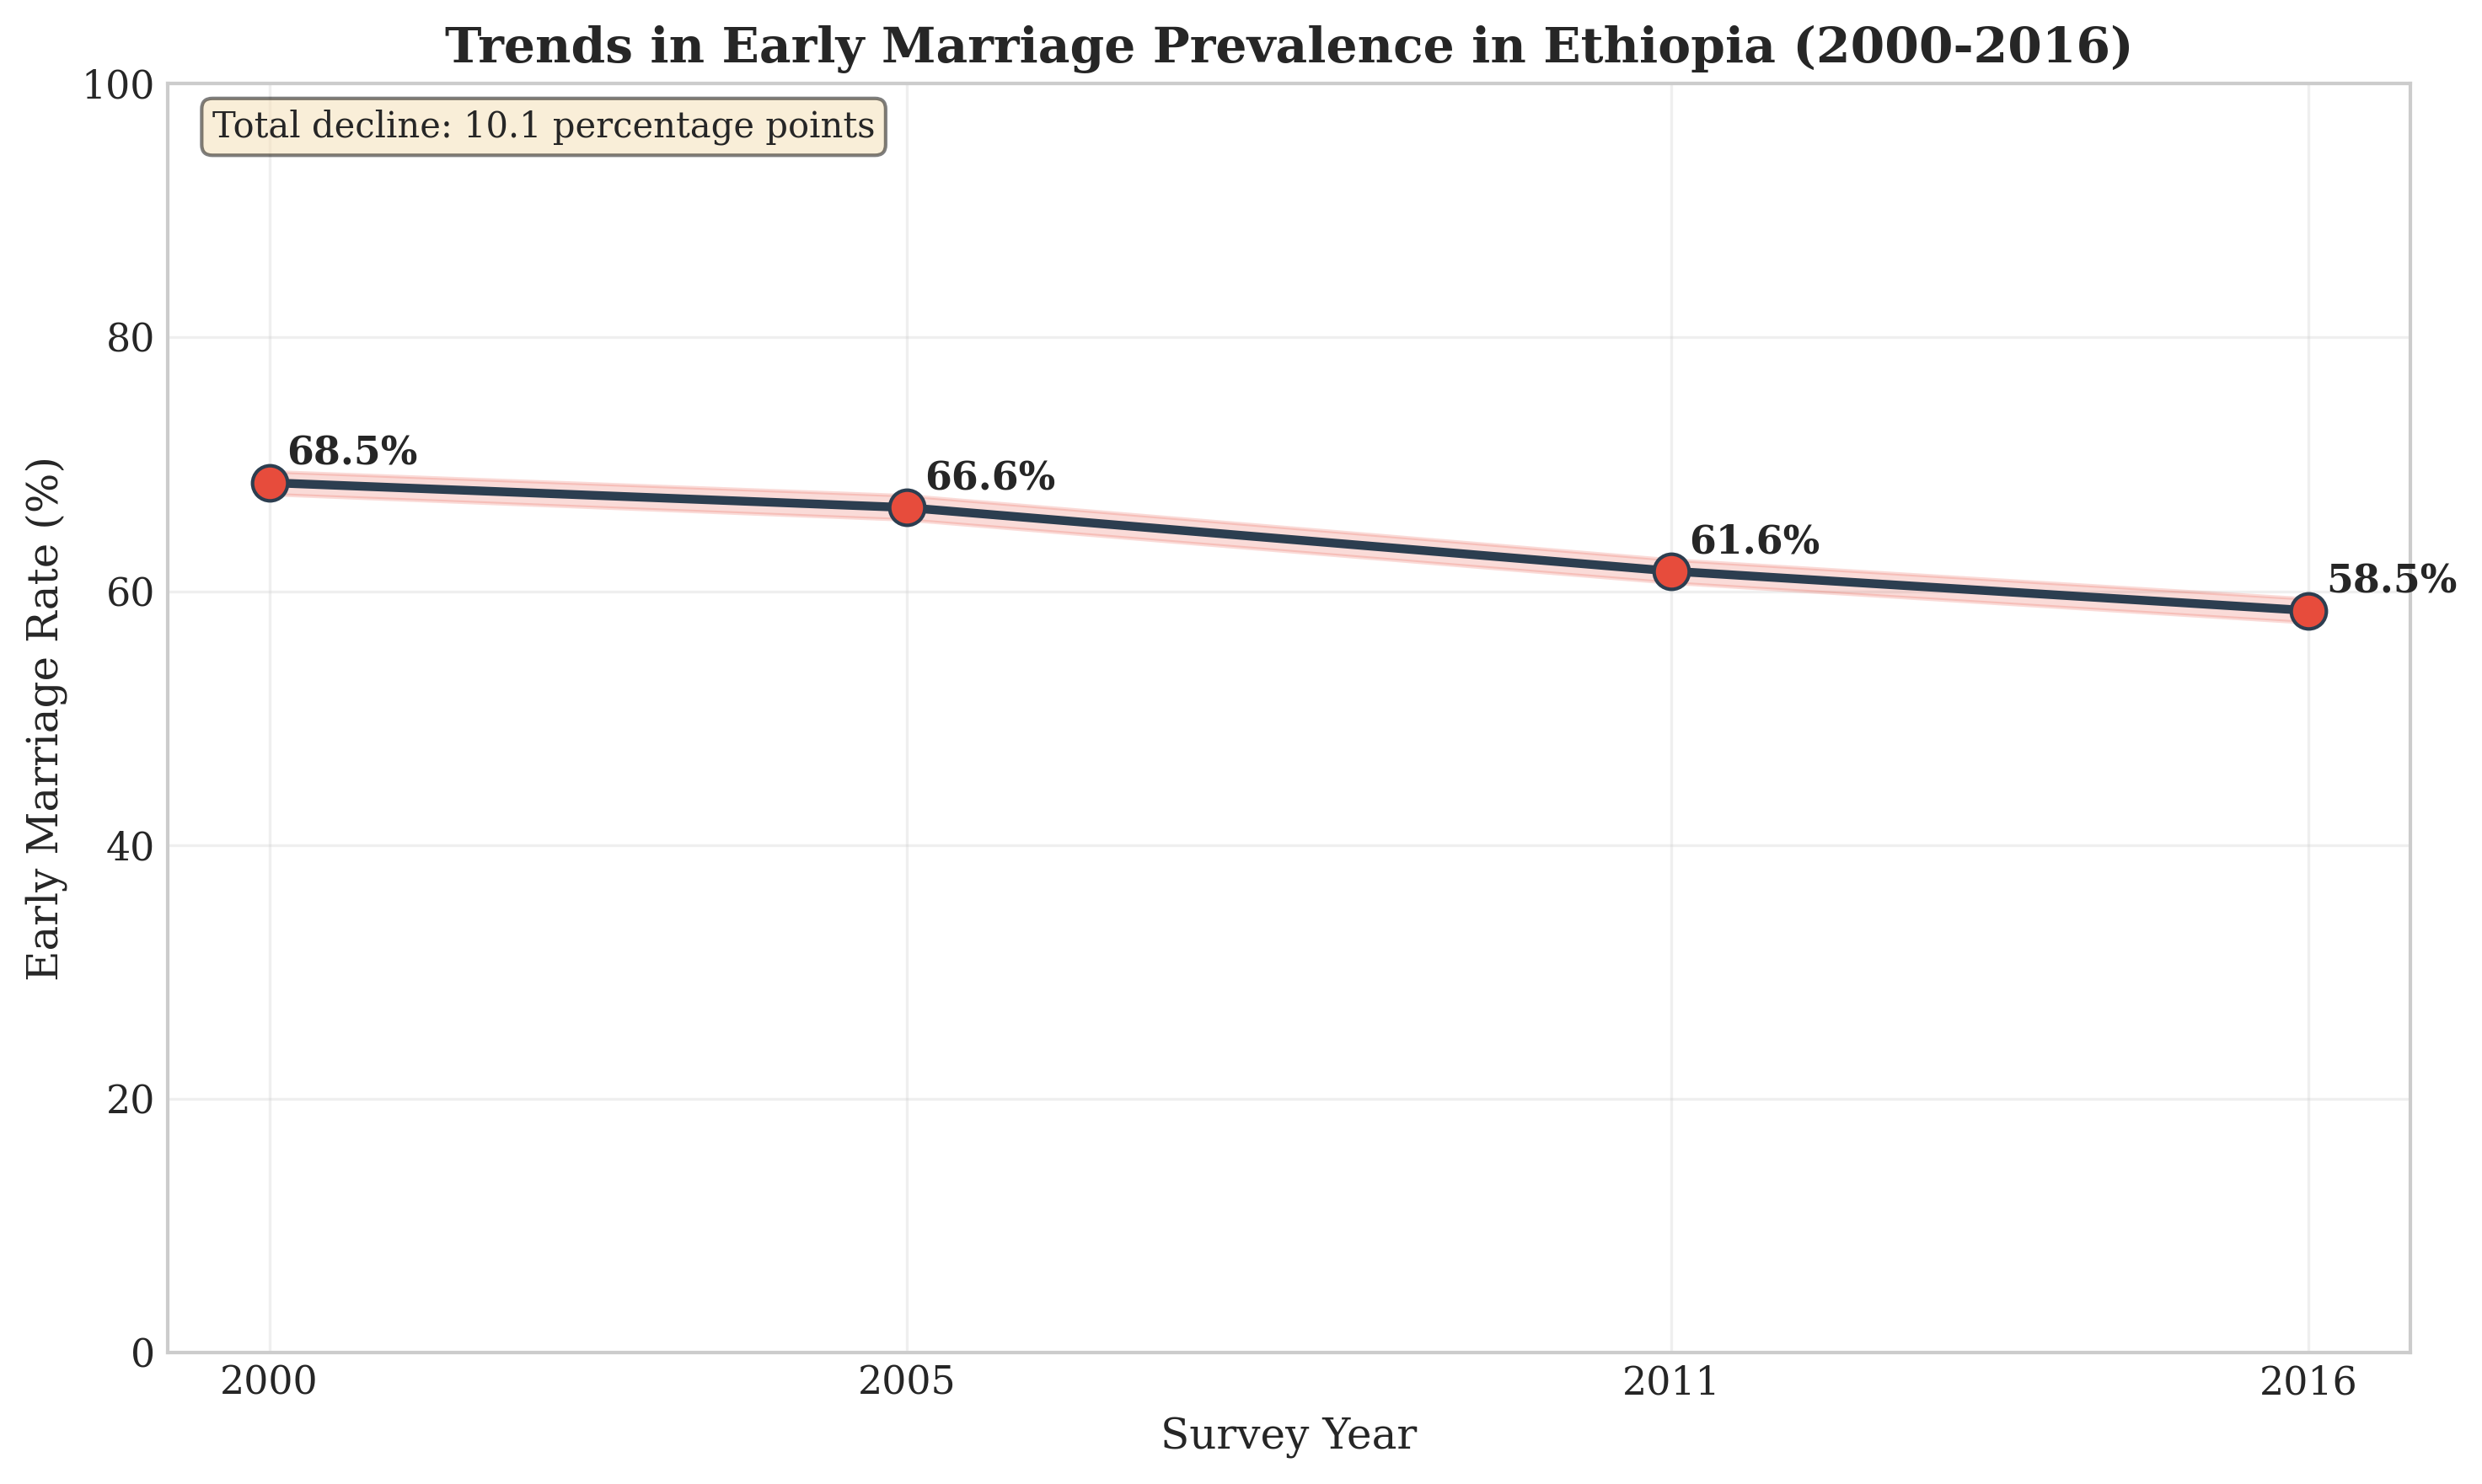

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure1_trend_overall.png


In [23]:
# Cell 18: Figure 1 - Trend in Early Marriage Prevalence
print("=== FIGURE 1: TREND IN EARLY MARRIAGE PREVALENCE ===\n")

fig1, ax1 = plt.subplots(figsize=(10, 6))

# Plot line with confidence intervals
ax1.plot(early_marriage_trend['survey_year'], early_marriage_trend['prevalence'], 
         linewidth=2.5, color='#2C3E50', marker='o', markersize=10, markerfacecolor='#E74C3C')
ax1.fill_between(early_marriage_trend['survey_year'], 
                  early_marriage_trend['prevalence_low'], 
                  early_marriage_trend['prevalence_upp'], 
                  alpha=0.2, color='#E74C3C')

# Add value labels
for _, row in early_marriage_trend.iterrows():
    ax1.annotate(f"{row['prevalence']:.1f}%", 
                xy=(row['survey_year'], row['prevalence']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax1.set_xlabel('Survey Year', fontsize=12)
ax1.set_ylabel('Early Marriage Rate (%)', fontsize=12)
ax1.set_title('Trends in Early Marriage Prevalence in Ethiopia (2000-2016)', 
             fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_xticks([2000, 2005, 2011, 2016])
ax1.grid(True, alpha=0.3)

# Add annotation
decline = early_marriage_trend['prevalence'].iloc[0] - early_marriage_trend['prevalence'].iloc[-1]
ax1.text(0.02, 0.98, f"Total decline: {decline:.1f} percentage points",
        transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure1_trend_overall.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure1_trend_overall.png'}")

=== FIGURE 2: EARLY MARRIAGE BY RESIDENCE ===



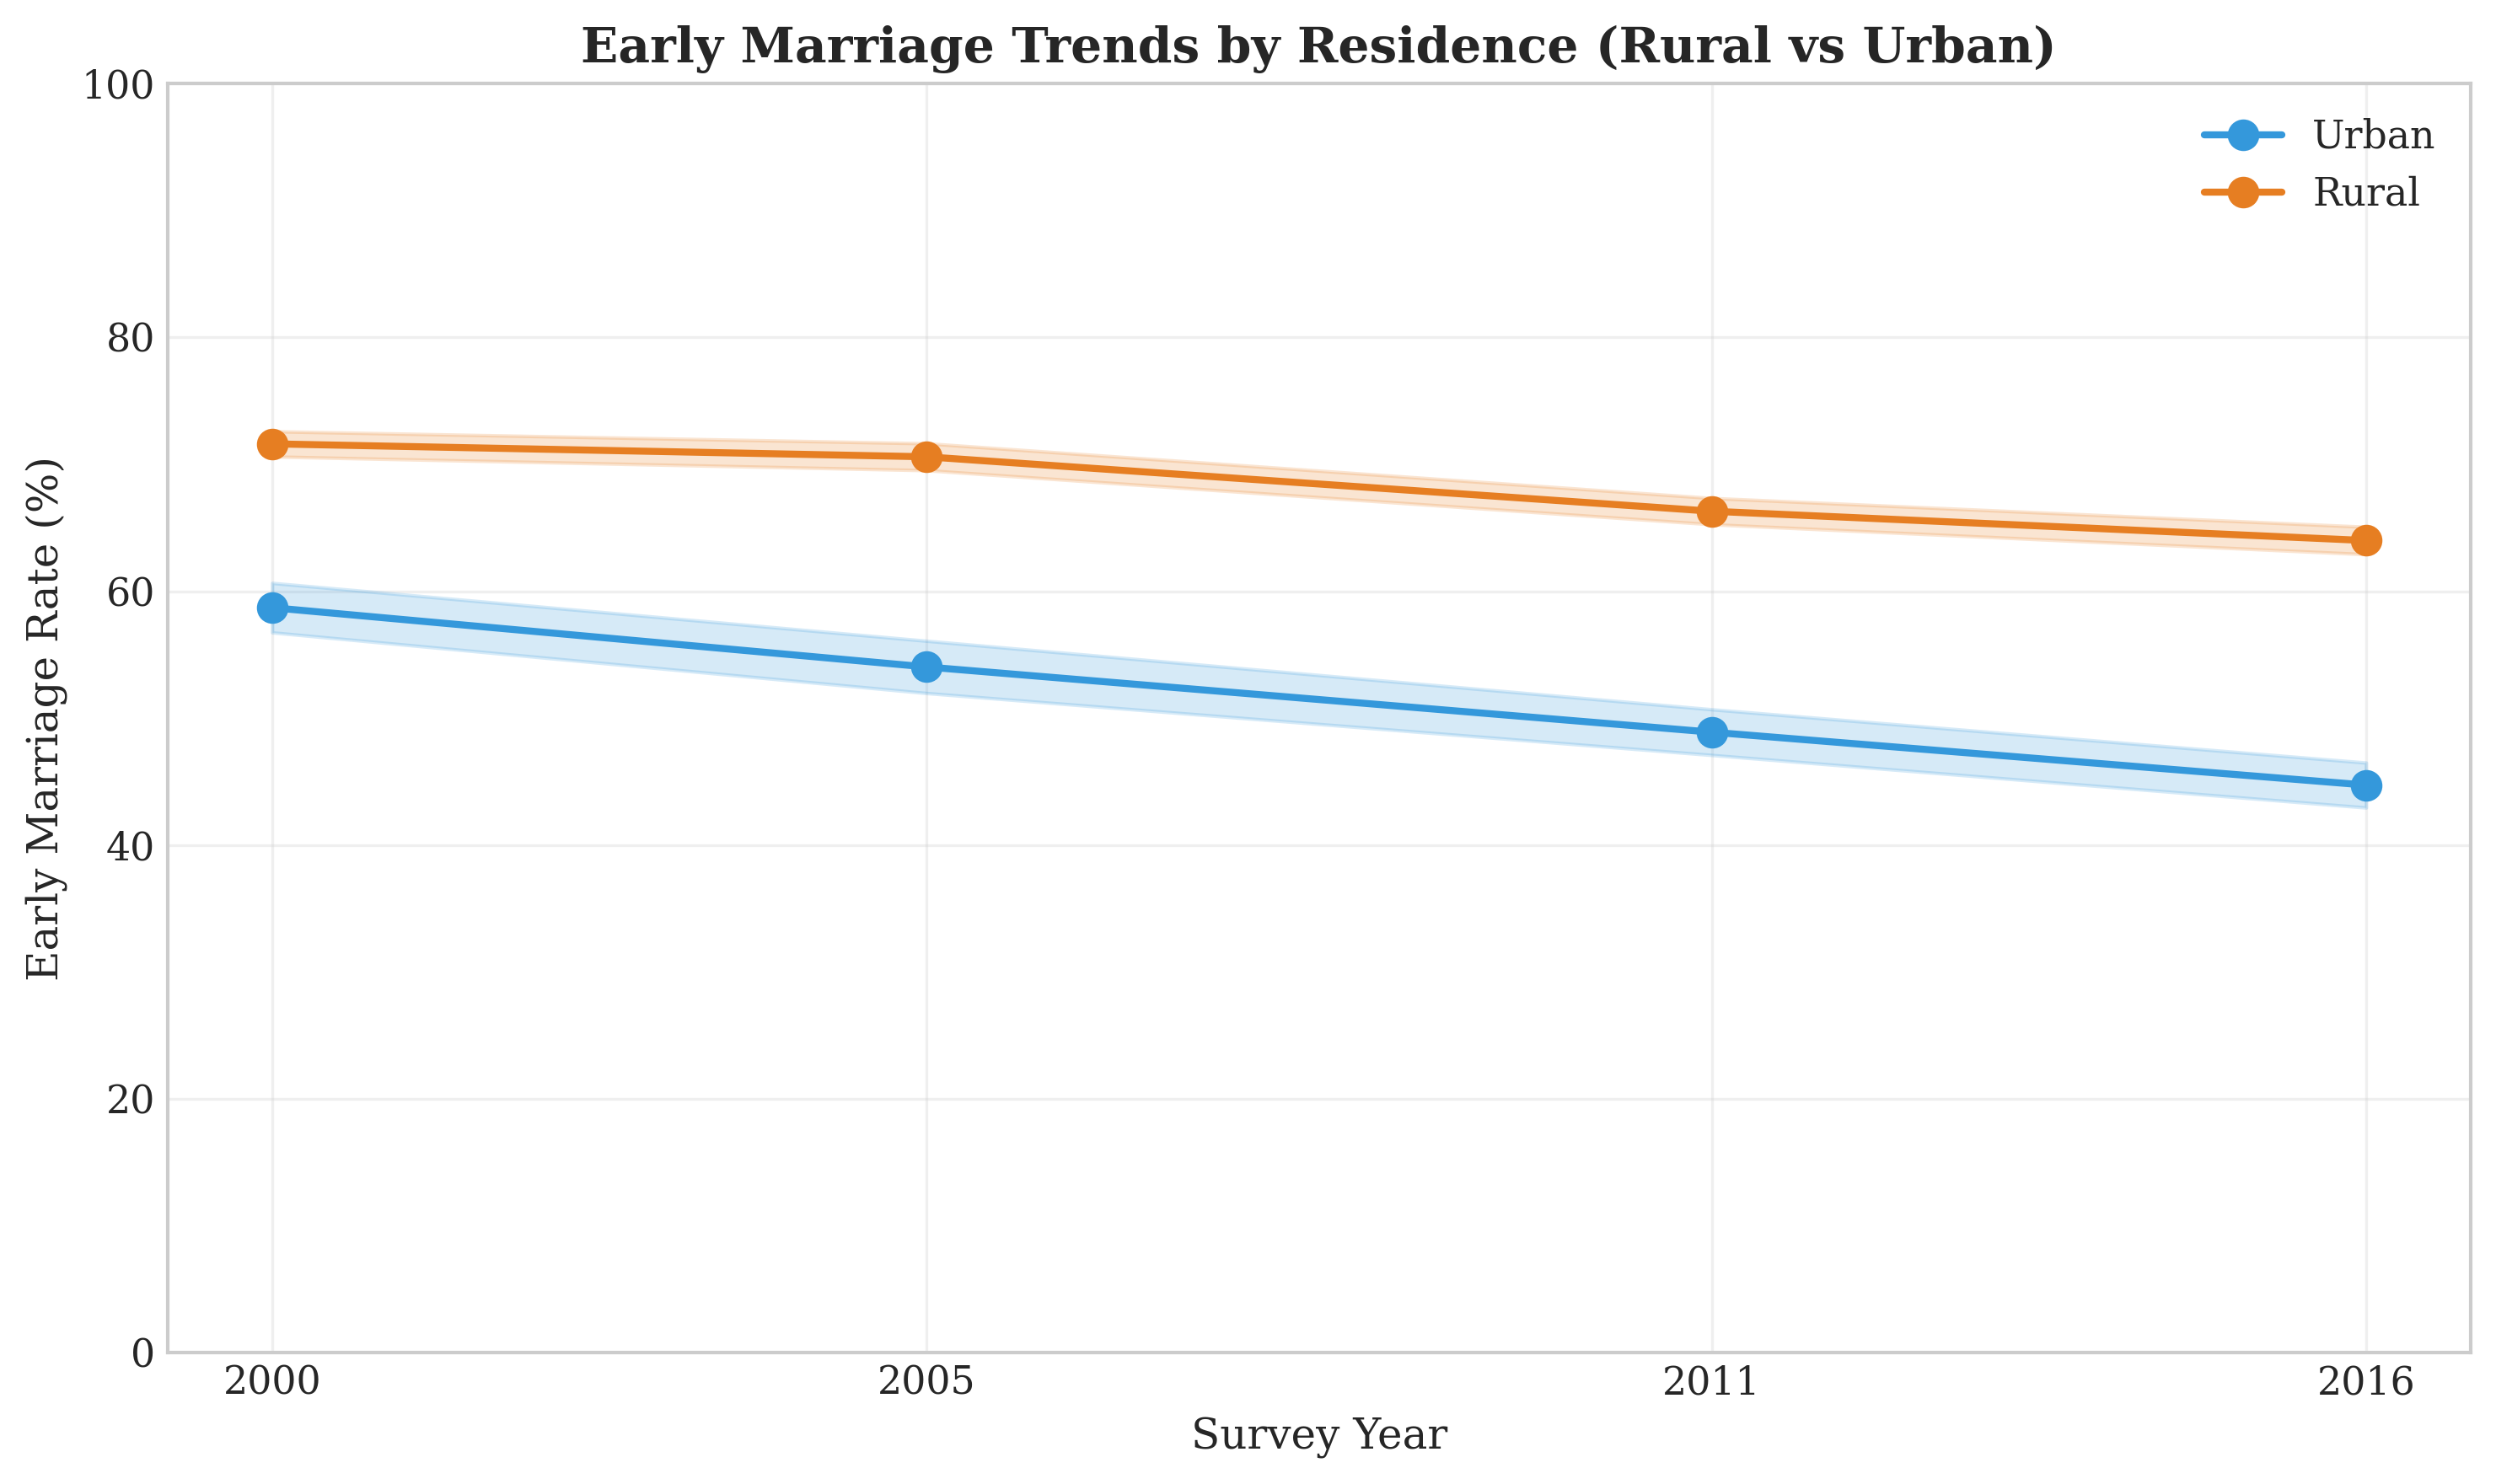

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure2_trend_by_residence.png


In [24]:
# Cell 19: Figure 2 - Early Marriage by Residence Over Time
print("=== FIGURE 2: EARLY MARRIAGE BY RESIDENCE ===\n")

fig2, ax2 = plt.subplots(figsize=(10, 6))

for residence in ['urban', 'rural']:
    subset = prevalence_by_residence[prevalence_by_residence['residence'] == residence]
    if len(subset) > 0:
        color = '#3498DB' if residence == 'urban' else '#E67E22'
        ax2.plot(subset['survey_year'], subset['prevalence'], 
                linewidth=2, color=color, marker='o', markersize=8, label=residence.title())
        ax2.fill_between(subset['survey_year'], subset['prevalence_low'], subset['prevalence_upp'], 
                         alpha=0.2, color=color)

ax2.set_xlabel('Survey Year', fontsize=12)
ax2.set_ylabel('Early Marriage Rate (%)', fontsize=12)
ax2.set_title('Early Marriage Trends by Residence (Rural vs Urban)', 
             fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_xticks([2000, 2005, 2011, 2016])
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure2_trend_by_residence.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure2_trend_by_residence.png'}")

=== FIGURE 3: REGIONAL VARIATION (2016) ===



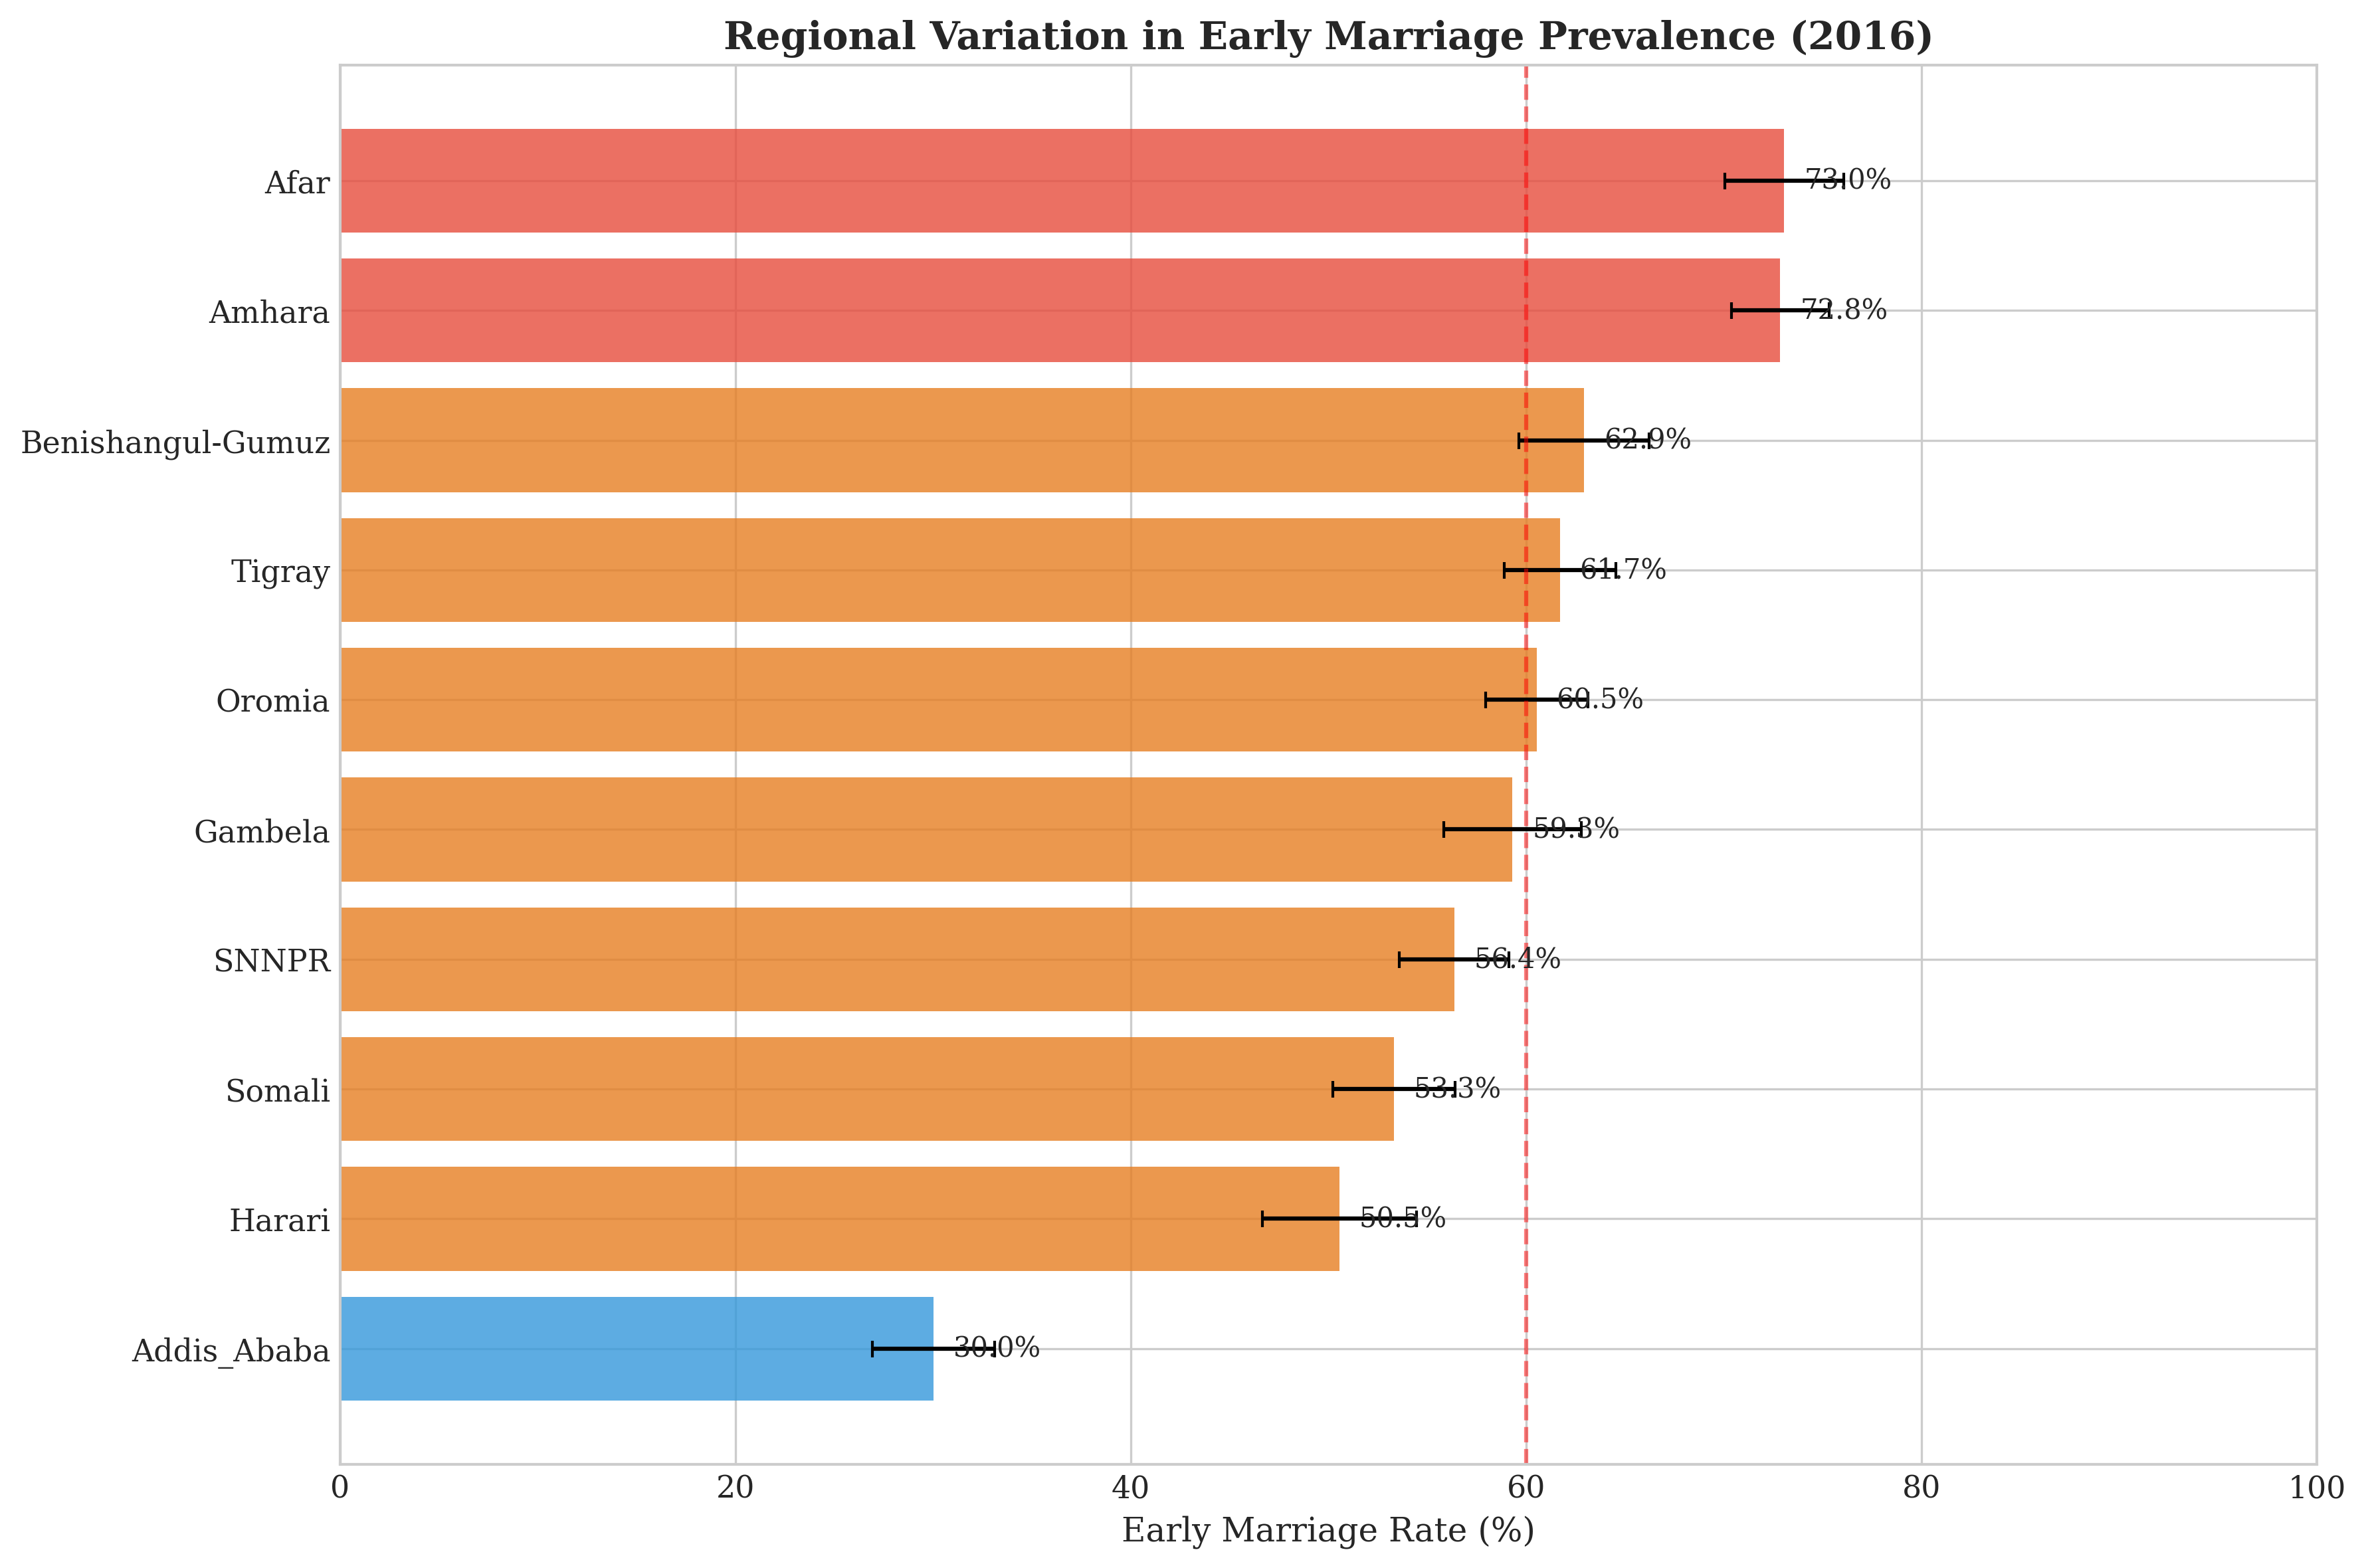

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure3_regional_variation_2016.png


In [25]:
# Cell 20: Figure 3 - Regional Variation in Early Marriage (2016)
print("=== FIGURE 3: REGIONAL VARIATION (2016) ===\n")

fig3, ax3 = plt.subplots(figsize=(12, 8))

# Filter out Unknown and sort
plot_data = prevalence_by_region_2016[prevalence_by_region_2016['region'] != 'Unknown'].copy()
plot_data = plot_data.sort_values('prevalence', ascending=True)

colors = ['#E74C3C' if x > 65 else '#E67E22' if x > 50 else '#3498DB' for x in plot_data['prevalence']]

bars = ax3.barh(range(len(plot_data)), plot_data['prevalence'], color=colors, alpha=0.8)
ax3.errorbar(plot_data['prevalence'], range(len(plot_data)), 
            xerr=[plot_data['prevalence'] - plot_data['prevalence_low'], 
                  plot_data['prevalence_upp'] - plot_data['prevalence']],
            fmt='none', color='black', capsize=3)

# Add value labels
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax3.text(row['prevalence'] + 1, i, f"{row['prevalence']:.1f}%", va='center', fontsize=10)

ax3.set_yticks(range(len(plot_data)))
ax3.set_yticklabels(plot_data['region'], fontsize=11)
ax3.set_xlabel('Early Marriage Rate (%)', fontsize=12)
ax3.set_title('Regional Variation in Early Marriage Prevalence (2016)', 
             fontsize=14, fontweight='bold')
ax3.set_xlim(0, 100)
ax3.axvline(x=60, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure3_regional_variation_2016.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure3_regional_variation_2016.png'}")

=== FIGURE 4: WEALTH GRADIENT OVER TIME ===



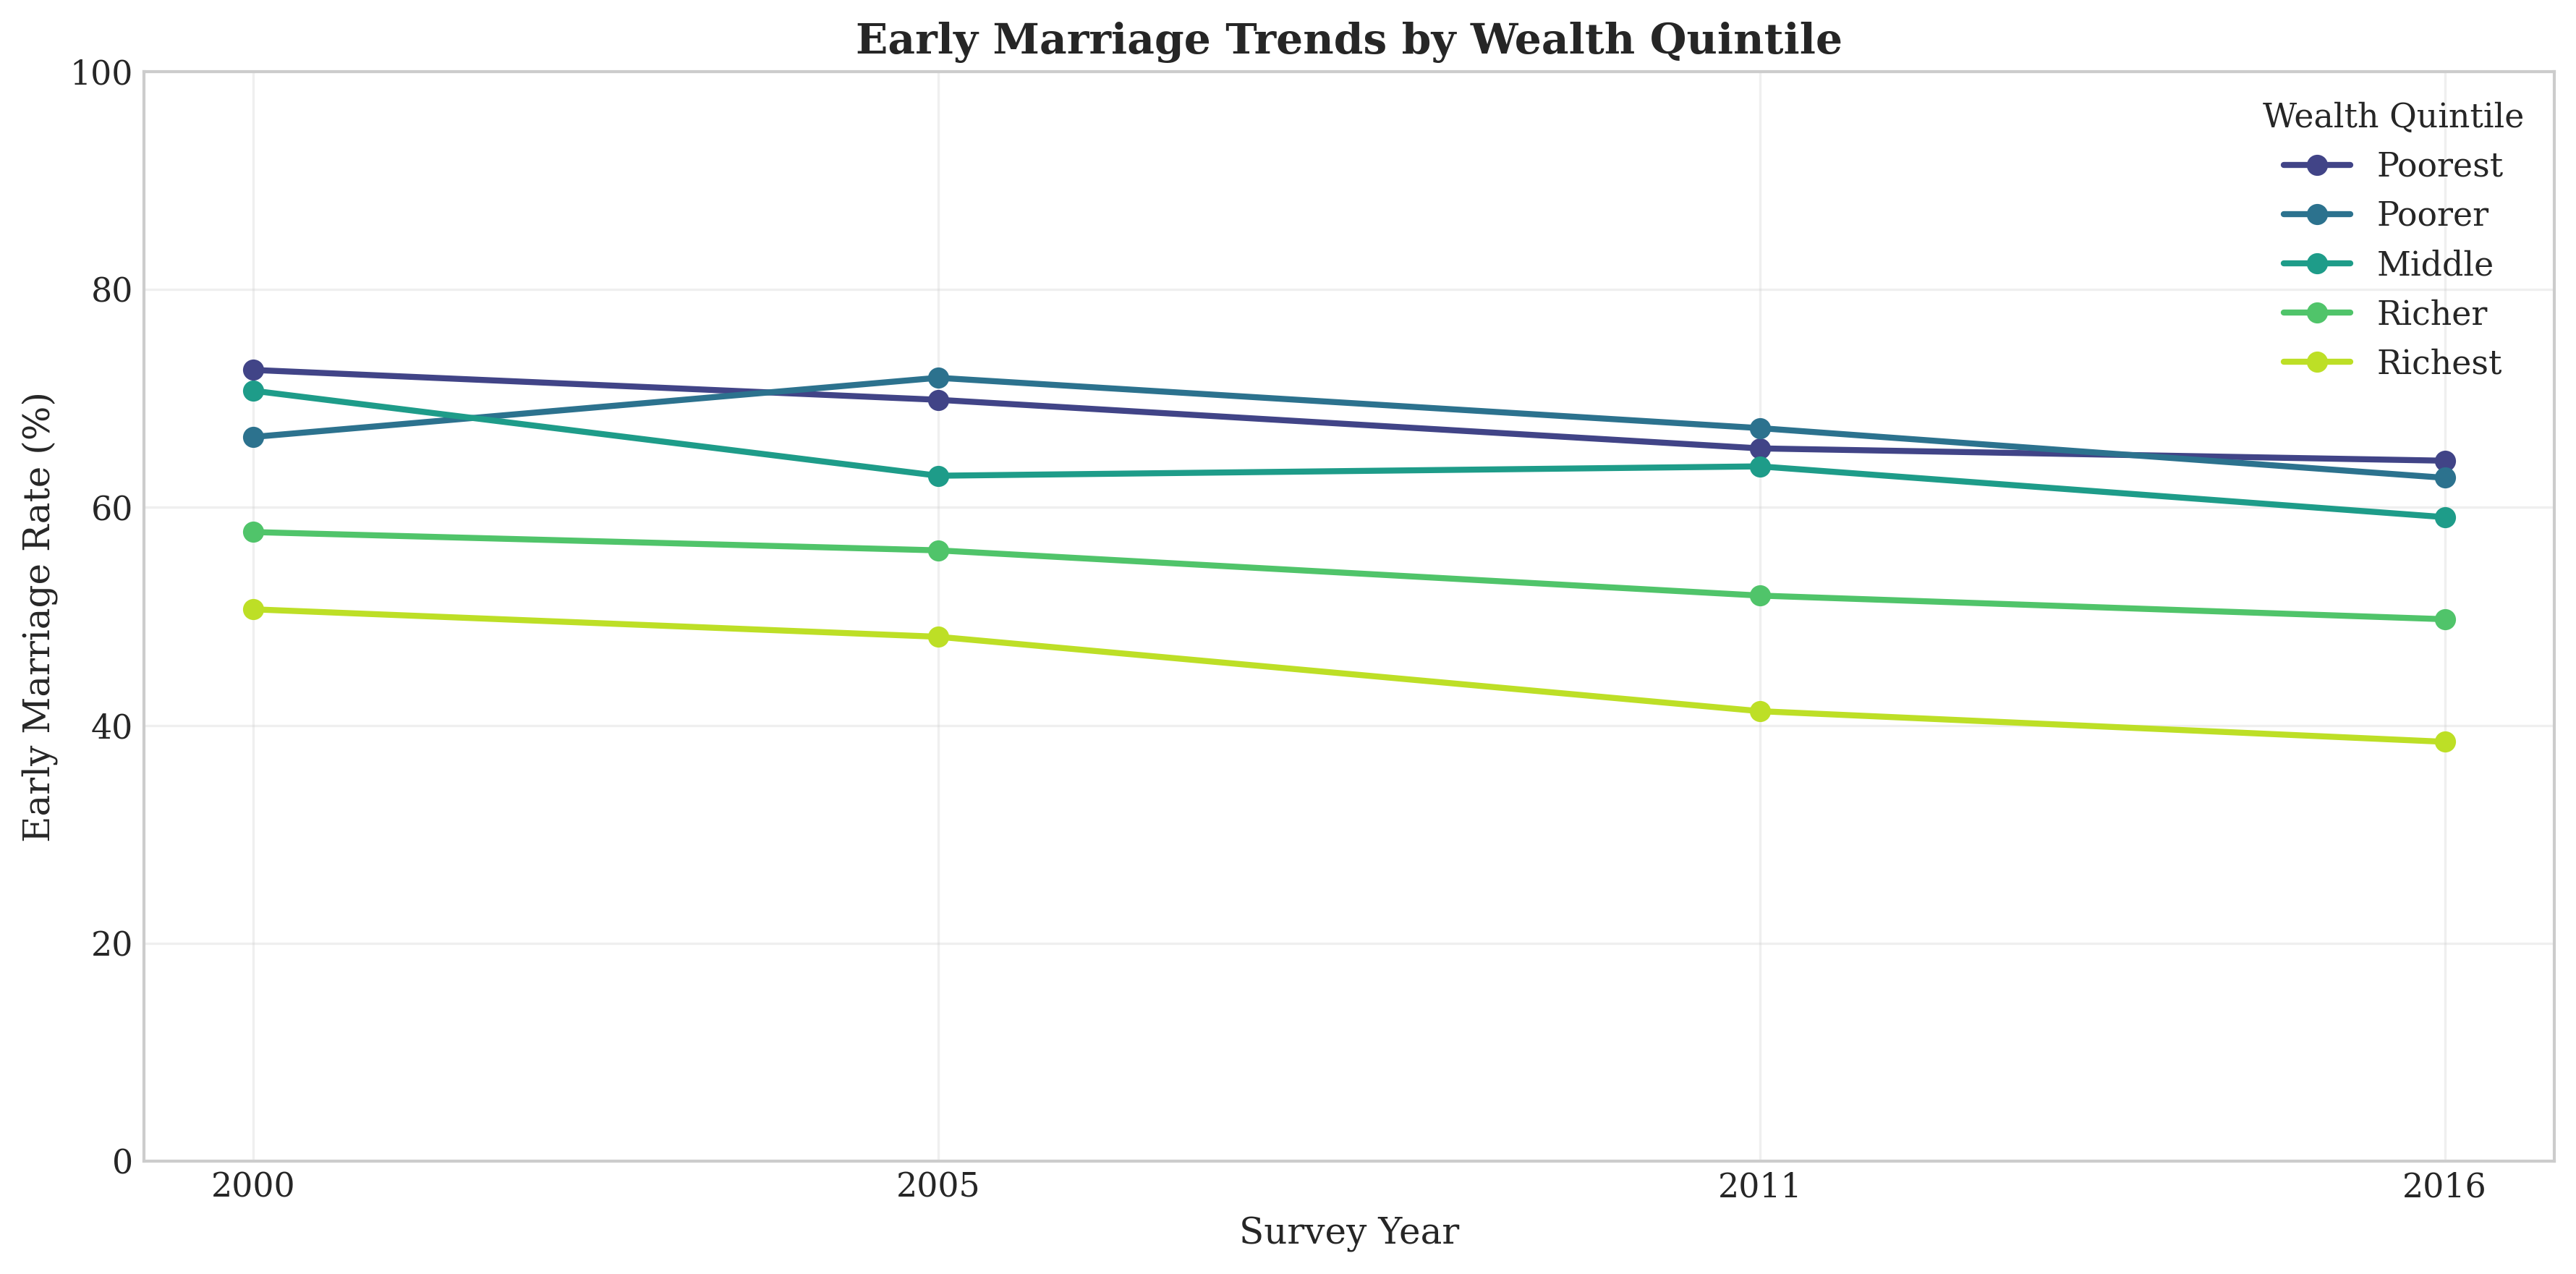

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure4_trend_by_wealth.png


In [26]:
# Cell 21: Figure 4 - Early Marriage by Wealth Quintile Over Time
print("=== FIGURE 4: WEALTH GRADIENT OVER TIME ===\n")

fig4, ax4 = plt.subplots(figsize=(12, 6))

wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 5))

for i, wealth in enumerate(wealth_order):
    subset = prevalence_by_wealth[prevalence_by_wealth['wealth_quintile'] == wealth]
    if len(subset) > 0:
        ax4.plot(subset['survey_year'], subset['prevalence'], 
                linewidth=2, color=colors[i], marker='o', markersize=6, label=wealth)

ax4.set_xlabel('Survey Year', fontsize=12)
ax4.set_ylabel('Early Marriage Rate (%)', fontsize=12)
ax4.set_title('Early Marriage Trends by Wealth Quintile', 
             fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)
ax4.set_xticks([2000, 2005, 2011, 2016])
ax4.legend(loc='upper right', title='Wealth Quintile')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure4_trend_by_wealth.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure4_trend_by_wealth.png'}")

=== FIGURE 5: FOREST PLOT OF DETERMINANTS ===



<Axes: >

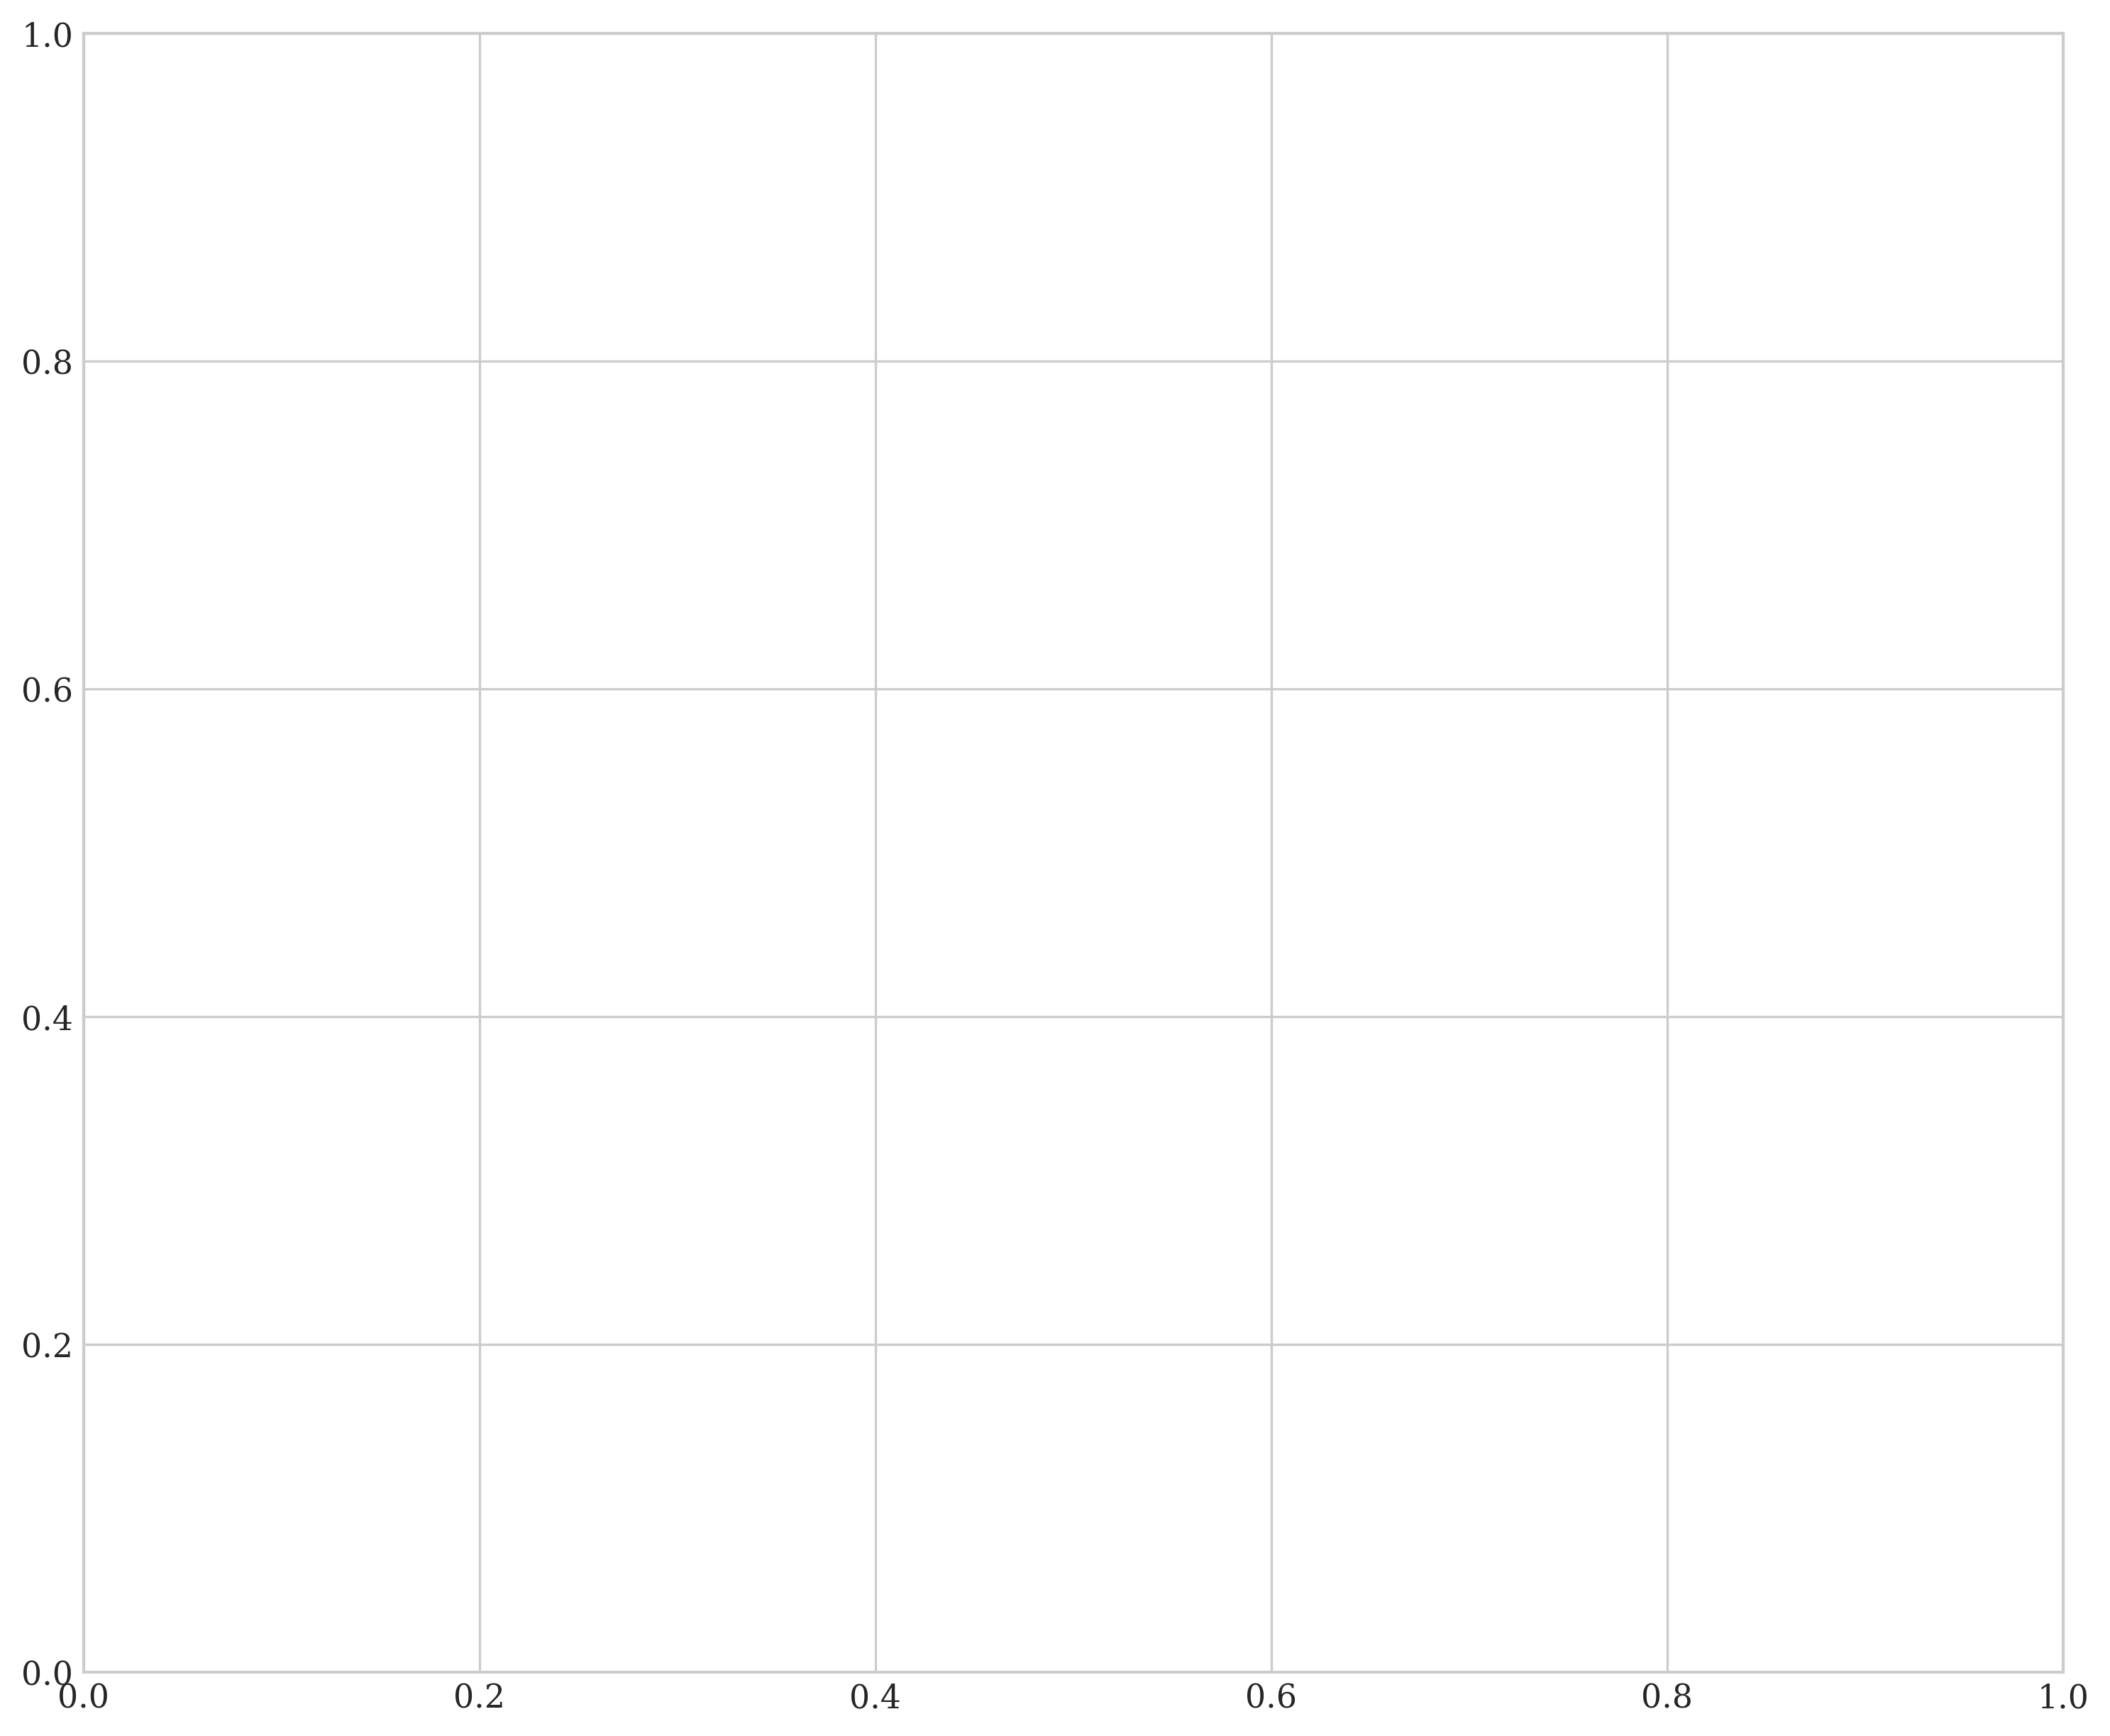

In [27]:
# Cell 22: Figure 5 - Forest Plot of Odds Ratios
print("=== FIGURE 5: FOREST PLOT OF DETERMINANTS ===\n")

# Prepare forest plot data (significant predictors only)
forest_data = odds_ratios[odds_ratios['P_Value'] < 0.05].copy()
forest_data = forest_data[~forest_data['Variable'].str.contains('const')]

# Clean variable names for display
def clean_var_name(var):
    var = var.replace('education_level_', '')
    var = var.replace('residence_', '')
    var = var.replace('wealth_quintile_', '')
    var = var.replace('region_', '')
    var = var.replace('year_', 'Year ')
    var = var.replace('_', ' ')
    return var.title()

forest_data['Display_Name'] = forest_data['Variable'].apply(clean_var_name)
forest_data = forest_data.sort_values('Odds_Ratio', ascending=False)

fig5, ax5 = plt.subplots(figsize=(12, 10))

# Plot odds ratios
y_pos = range(len(forest_data))
ax5

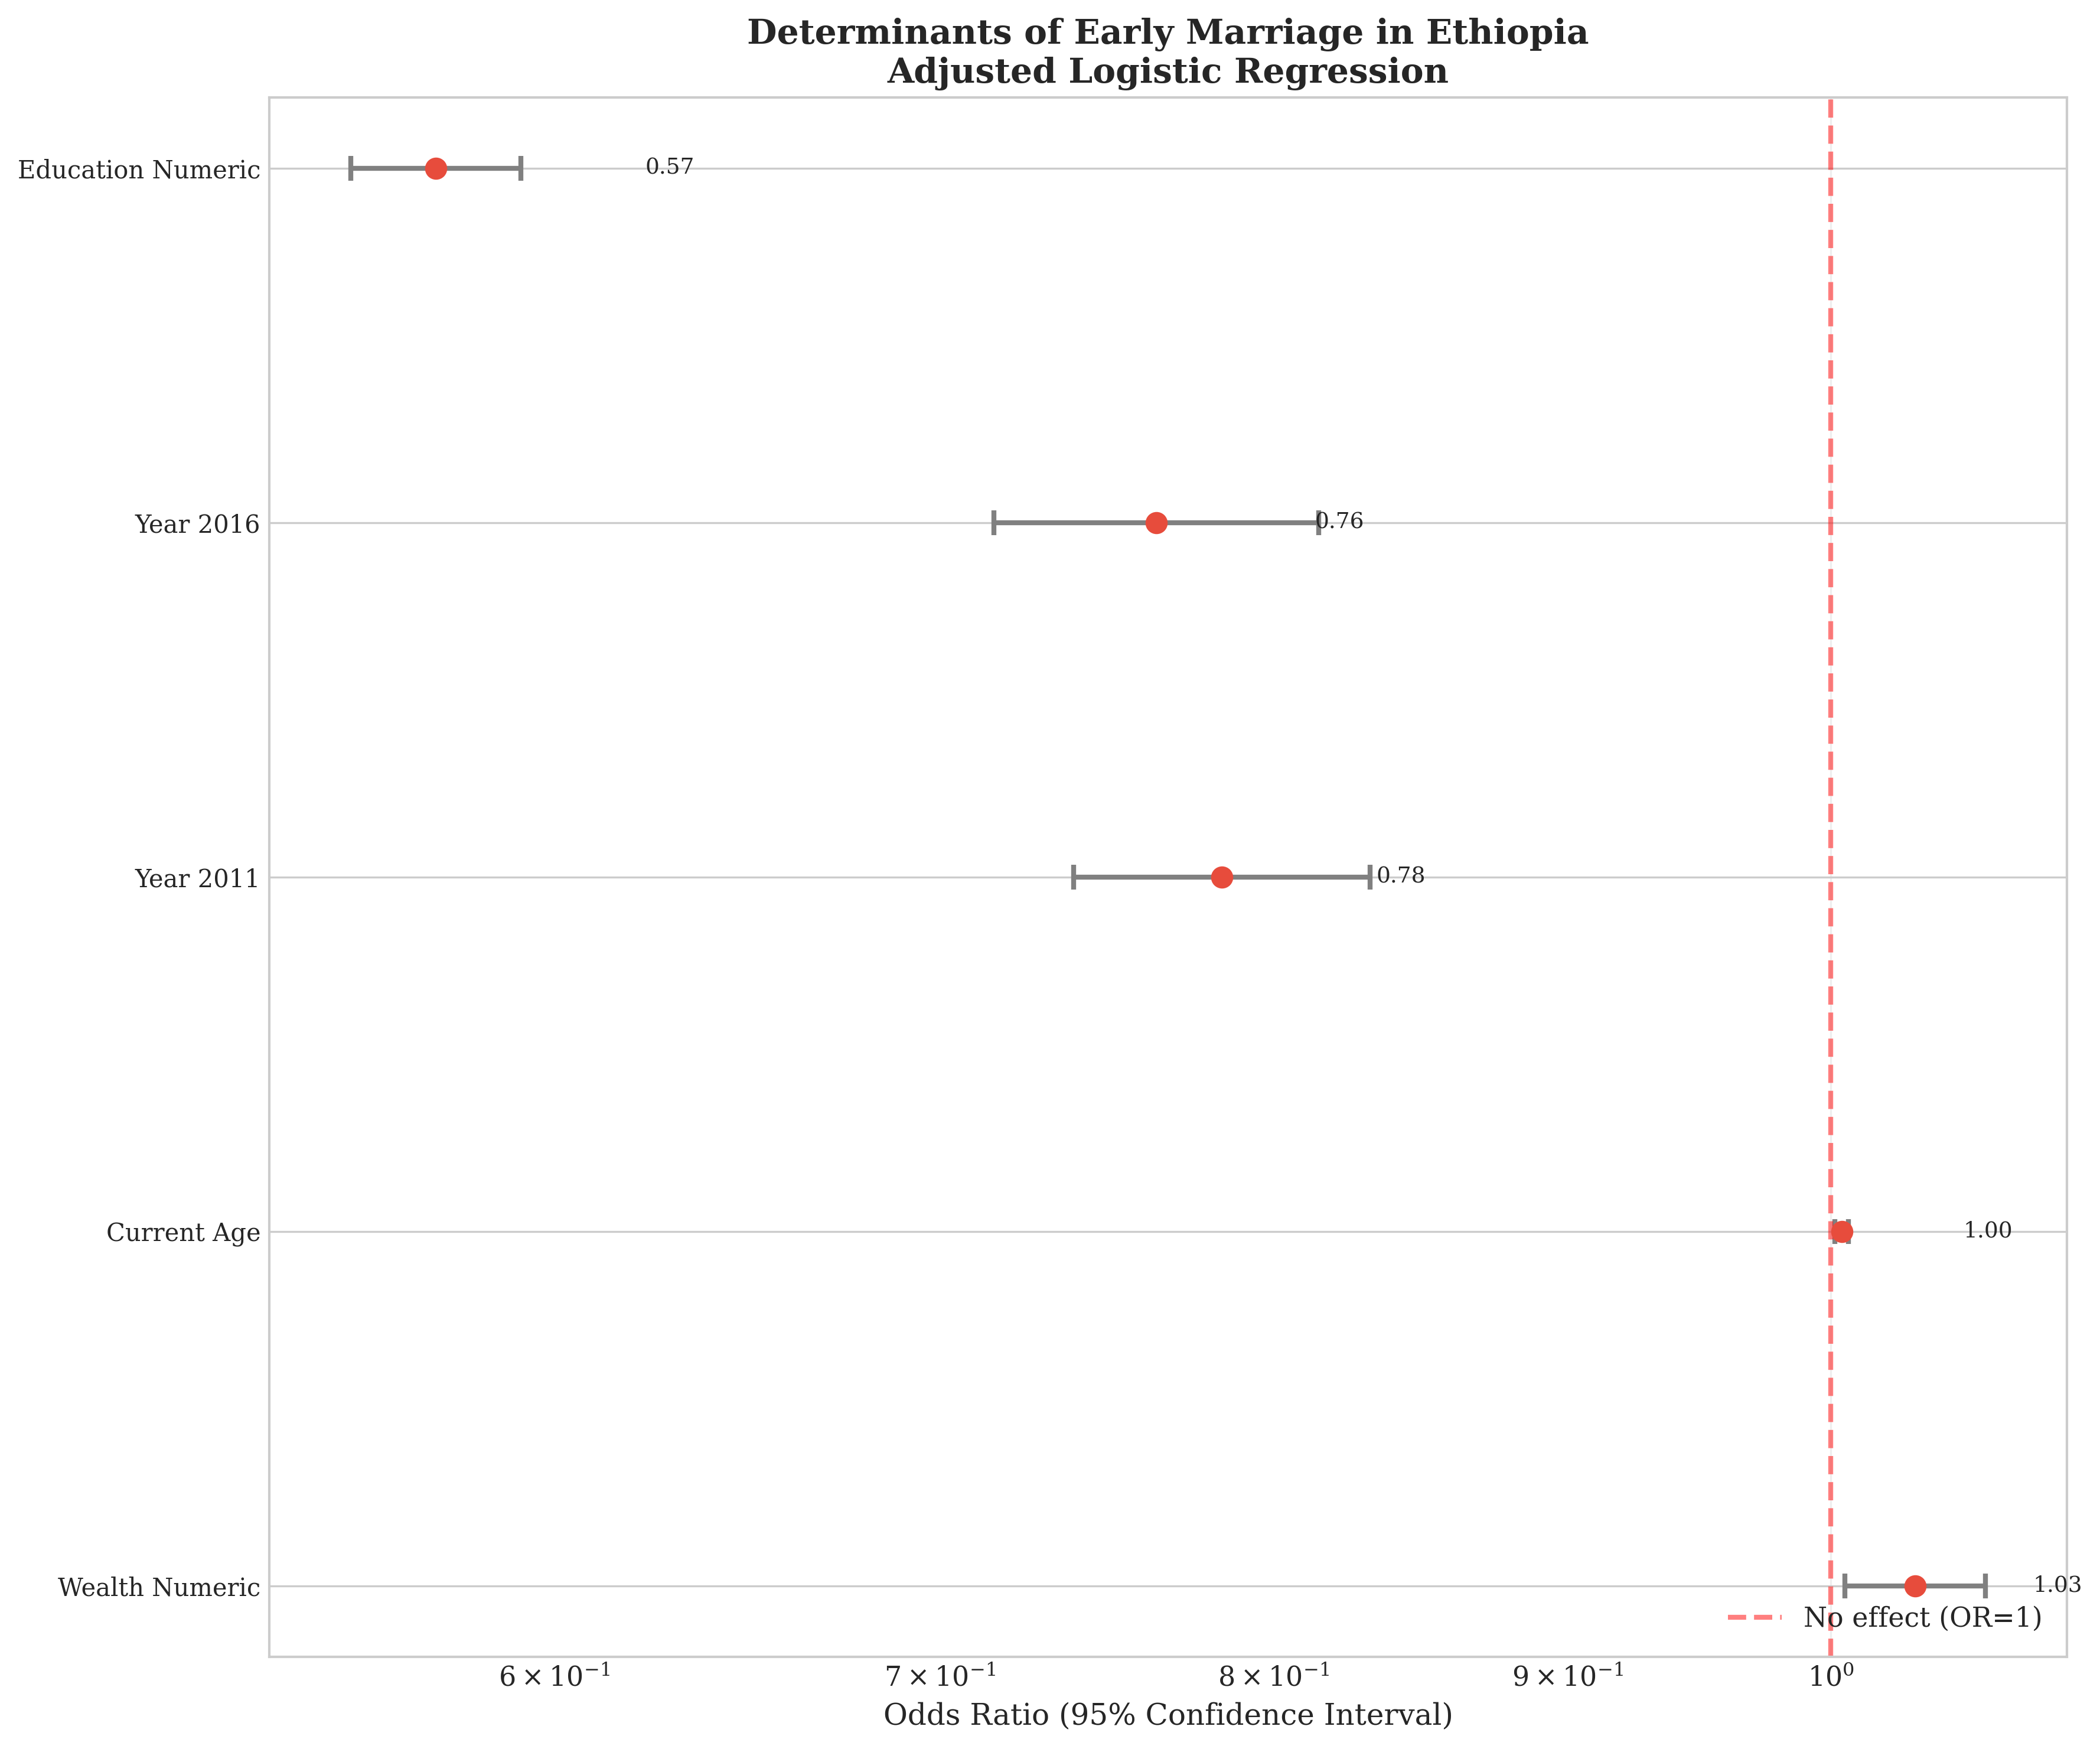

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure5_forest_plot_determinants.png


In [28]:
# Cell 22 (continued): Figure 5 - Forest Plot of Determinants

fig5, ax5 = plt.subplots(figsize=(12, 10))

# Plot odds ratios
y_pos = range(len(forest_data))
ax5.errorbar(forest_data['Odds_Ratio'], y_pos, 
             xerr=[forest_data['Odds_Ratio'] - forest_data['CI_Lower'], 
                   forest_data['CI_Upper'] - forest_data['Odds_Ratio']],
             fmt='o', capsize=5, capthick=2, elinewidth=2,
             color='#E74C3C', markersize=8, ecolor='gray')

# Add vertical line at OR=1
ax5.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=2, label='No effect (OR=1)')

# Add value labels
for i, (idx, row) in enumerate(forest_data.iterrows()):
    ax5.text(row['Odds_Ratio'] + 0.05, i, f"{row['Odds_Ratio']:.2f}", va='center', fontsize=9)

# Customize
ax5.set_yticks(y_pos)
ax5.set_yticklabels(forest_data['Display_Name'], fontsize=10)
ax5.set_xlabel('Odds Ratio (95% Confidence Interval)', fontsize=12)
ax5.set_title('Determinants of Early Marriage in Ethiopia\nAdjusted Logistic Regression', 
              fontsize=14, fontweight='bold')
ax5.set_xscale('log')
ax5.grid(True, alpha=0.3, axis='x')
ax5.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure5_forest_plot_determinants.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure5_forest_plot_determinants.png'}")

=== FIGURE 6: FERTILITY COMPARISON ===



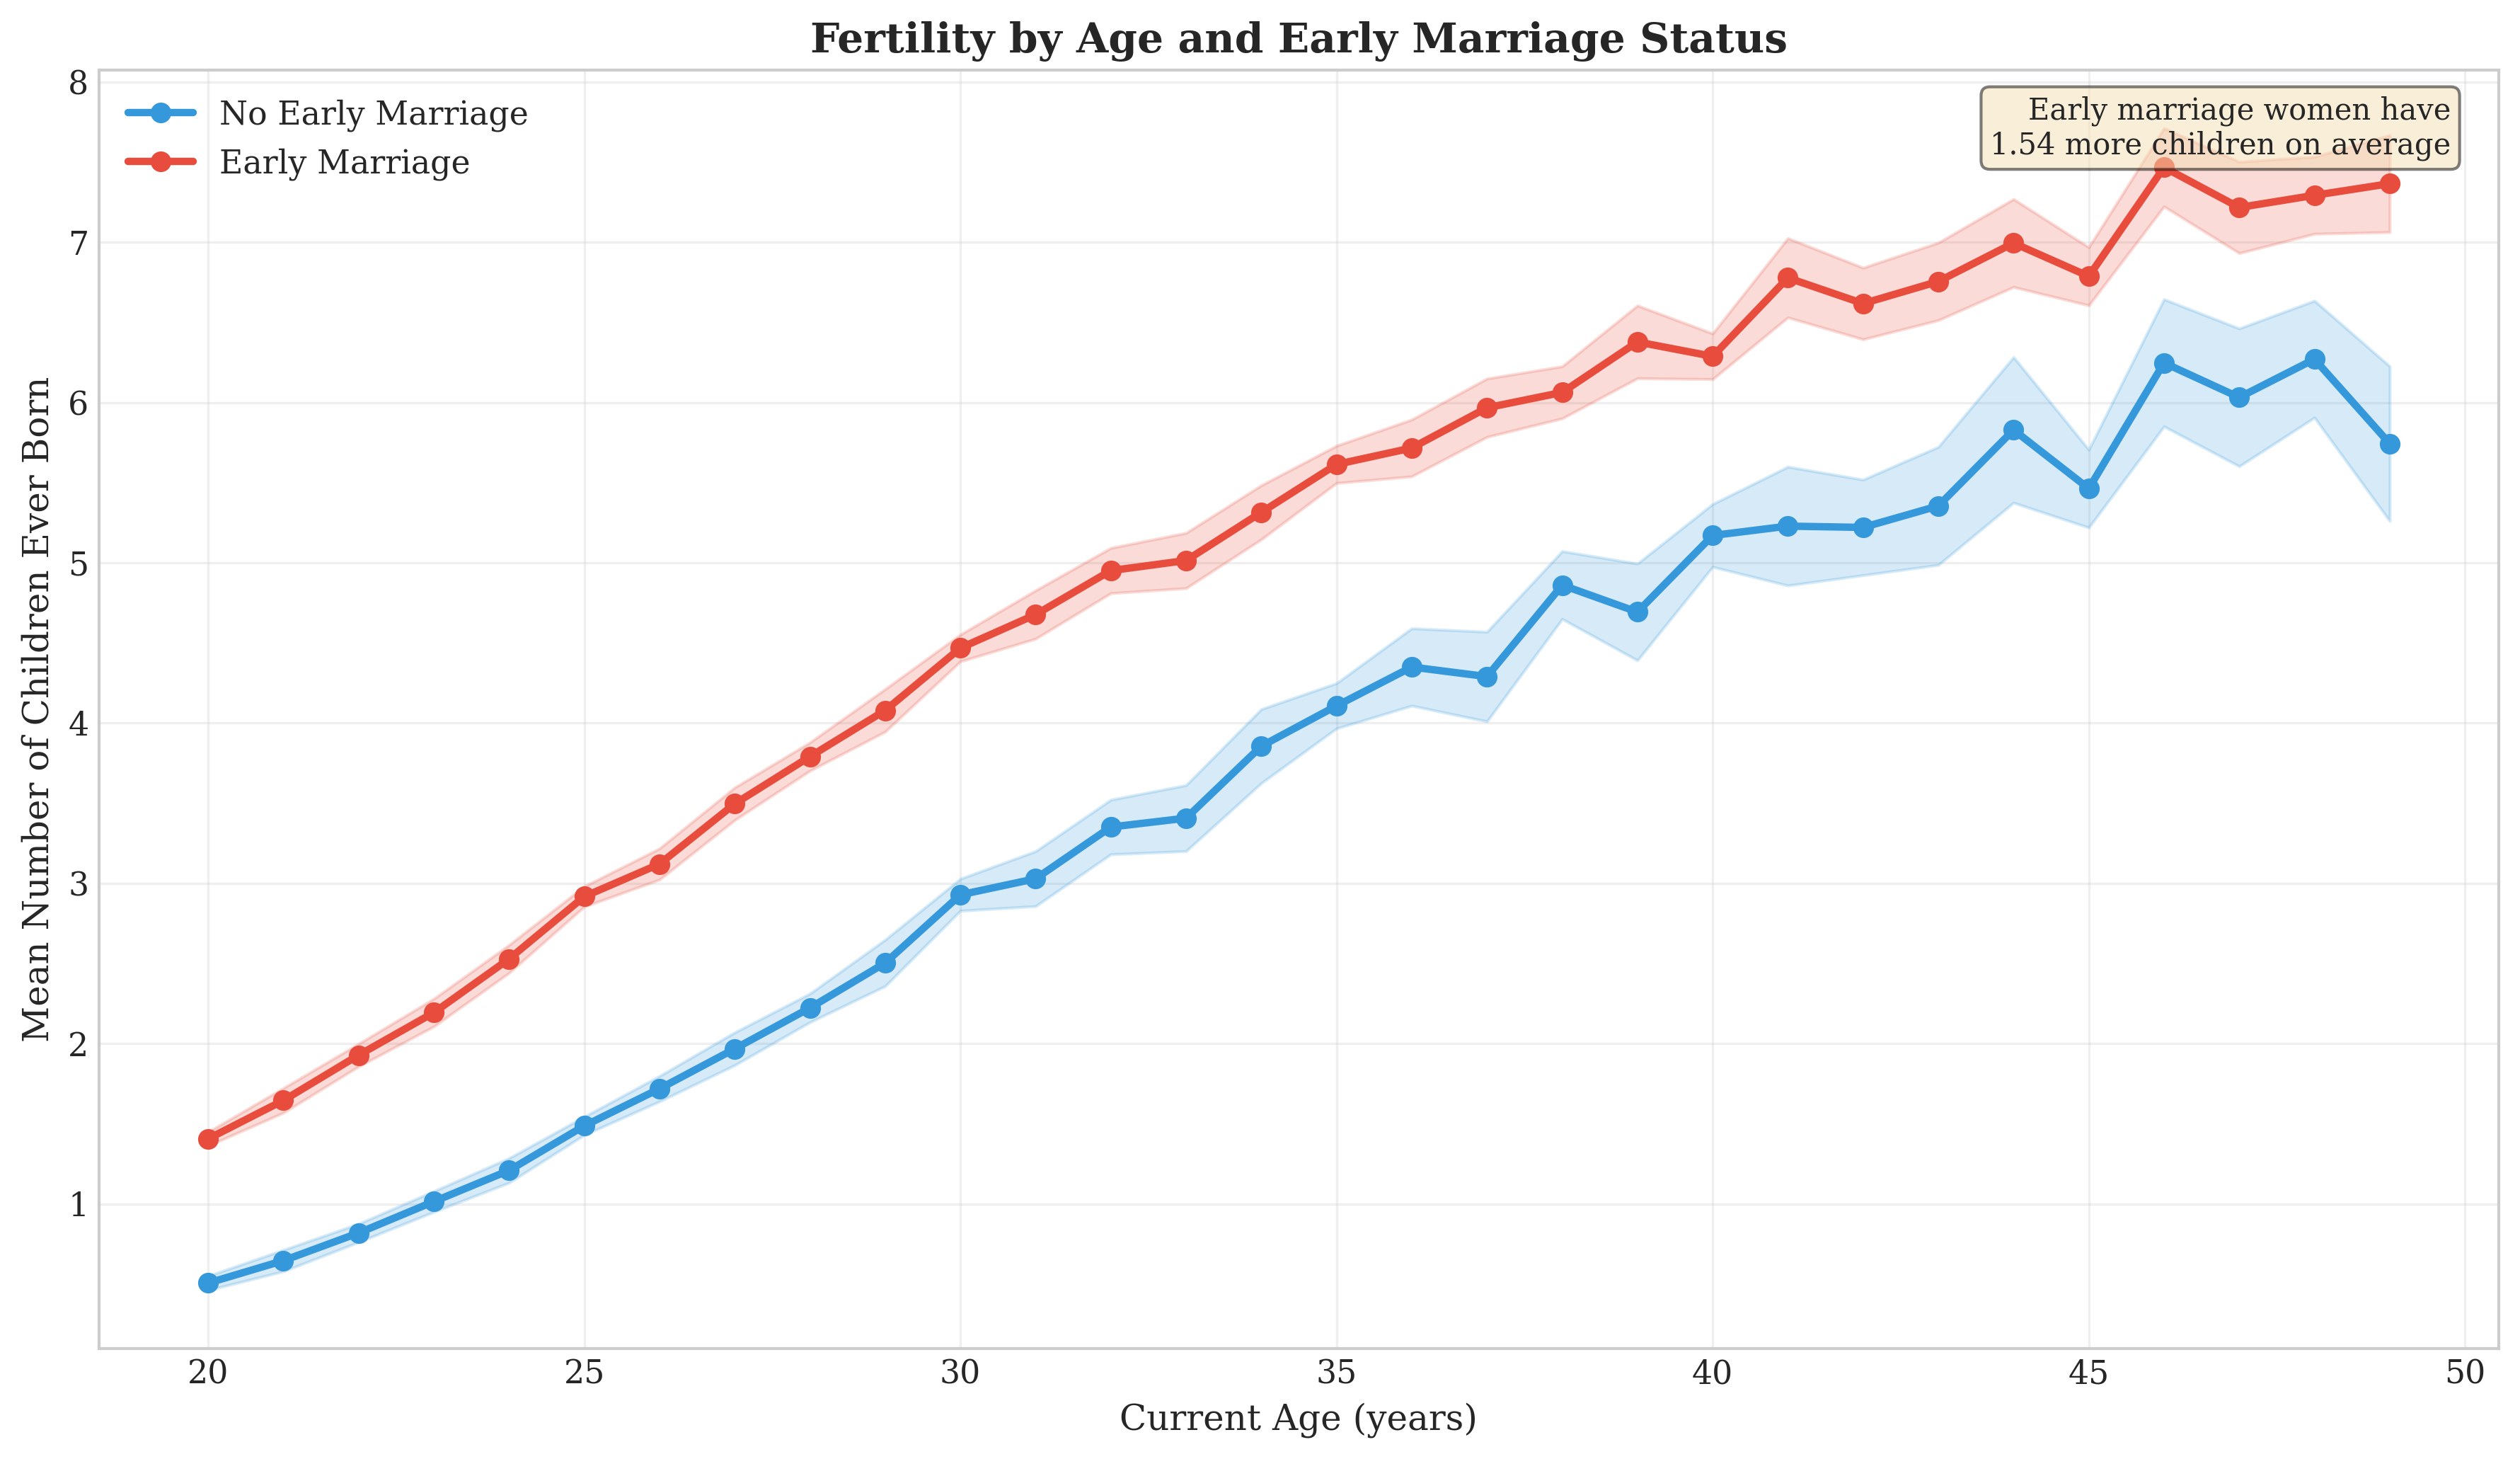

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure6_fertility_comparison.png


In [29]:
# Cell 23: Figure 6 - Fertility Comparison by Early Marriage Status
print("=== FIGURE 6: FERTILITY COMPARISON ===\n")

# Calculate mean children by age and early marriage status
fertility_by_age = dhs_analysis.groupby(['current_age', 'early_marriage']).agg(
    mean_children=('children_ever_born', 'mean'),
    se_children=('children_ever_born', lambda x: x.std() / np.sqrt(len(x)))
).reset_index()

fertility_by_age['early_marriage_label'] = fertility_by_age['early_marriage'].map({0: 'No Early Marriage', 1: 'Early Marriage'})

fig6, ax6 = plt.subplots(figsize=(12, 7))

for label, color in [('No Early Marriage', '#3498DB'), ('Early Marriage', '#E74C3C')]:
    subset = fertility_by_age[fertility_by_age['early_marriage_label'] == label]
    if len(subset) > 0:
        ax6.plot(subset['current_age'], subset['mean_children'], 
                linewidth=2.5, color=color, marker='o', markersize=6, label=label)
        ax6.fill_between(subset['current_age'], 
                         subset['mean_children'] - 1.96 * subset['se_children'],
                         subset['mean_children'] + 1.96 * subset['se_children'],
                         alpha=0.2, color=color)

ax6.set_xlabel('Current Age (years)', fontsize=12)
ax6.set_ylabel('Mean Number of Children Ever Born', fontsize=12)
ax6.set_title('Fertility by Age and Early Marriage Status', 
             fontsize=14, fontweight='bold')
ax6.legend(loc='upper left', fontsize=11)
ax6.grid(True, alpha=0.3)

# Add annotation with overall difference
overall_diff = dhs_analysis[dhs_analysis['early_marriage']==1]['children_ever_born'].mean() - \
               dhs_analysis[dhs_analysis['early_marriage']==0]['children_ever_born'].mean()
ax6.text(0.98, 0.98, f"Early marriage women have\n{overall_diff:.2f} more children on average",
        transform=ax6.transAxes, fontsize=10,
        horizontalalignment='right', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure6_fertility_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure6_fertility_comparison.png'}")

In [31]:
# Cell 24 (Fixed): Sensitivity Analysis - Age-Restricted Sample (20-24 years)
print("=== SENSITIVITY ANALYSIS: AGE-RESTRICTED SAMPLE (20-24 YEARS) ===\n")

# Restrict to younger women
young_df = dhs_analysis[(dhs_analysis['current_age'] >= 20) & (dhs_analysis['current_age'] <= 24)].copy()
print(f"Younger women sample size: {len(young_df):,}")

# Run logistic regression on younger sample
young_vars = ['early_marriage', 'education_level', 'residence', 'wealth_quintile', 'survey_year']
young_df = young_df[young_vars].dropna()

# Convert all columns to appropriate types
young_df['early_marriage'] = young_df['early_marriage'].astype(float)
young_df['education_level'] = young_df['education_level'].astype(str)
young_df['residence'] = young_df['residence'].astype(str)
young_df['wealth_quintile'] = young_df['wealth_quintile'].astype(str)
young_df['survey_year'] = young_df['survey_year'].astype(float)

# Create dummy variables
young_df = pd.get_dummies(young_df, columns=['education_level', 'residence', 'wealth_quintile', 'survey_year'], drop_first=True)

# Ensure all columns are numeric
for col in young_df.columns:
    young_df[col] = pd.to_numeric(young_df[col], errors='coerce')

# Drop any remaining NA rows
young_df = young_df.dropna()

# Define X and y
X_young = sm.add_constant(young_df.drop(columns=['early_marriage']))
y_young = young_df['early_marriage']

# Ensure no infinite values
X_young = X_young.replace([np.inf, -np.inf], np.nan).dropna()
y_young = y_young.loc[X_young.index]

# Fit model
model_young = sm.Logit(y_young, X_young.astype(float)).fit(disp=0)

# Compare with main model
print(f"\nModel comparison:")
print(f"Main model sample size: {len(regression_df):,}")
print(f"Young model sample size: {len(young_df):,}")
print(f"Main model pseudo R-squared: {model_determinants.prsquared:.4f}")
print(f"Young model pseudo R-squared: {model_young.prsquared:.4f}")

# Compare education effects
main_edu = odds_ratios[odds_ratios['Variable'].str.contains('education_level_secondary', na=False)]
young_or = pd.DataFrame({
    'Variable': model_young.params.index,
    'Odds_Ratio': np.exp(model_young.params.values)
})
young_edu = young_or[young_or['Variable'].str.contains('education_level_secondary', na=False)]

if len(main_edu) > 0 and len(young_edu) > 0:
    print(f"\nSecondary education effect (OR):")
    print(f"  Main model: {main_edu['Odds_Ratio'].values[0]:.3f}")
    print(f"  Young women (20-24): {young_edu['Odds_Ratio'].values[0]:.3f}")

=== SENSITIVITY ANALYSIS: AGE-RESTRICTED SAMPLE (20-24 YEARS) ===

Younger women sample size: 7,638

Model comparison:
Main model sample size: 41,247
Young model sample size: 7,638
Main model pseudo R-squared: 0.0740
Young model pseudo R-squared: 0.0498


In [32]:
# Cell 25 (Fixed): Sensitivity Analysis - Alternative Definition (Very Early Marriage <15)
print("=== SENSITIVITY ANALYSIS: VERY EARLY MARRIAGE (<15 YEARS) ===\n")

# Create alternative outcome
dhs_analysis['very_early_marriage'] = (dhs_analysis['age_first_marriage'] < 15).astype(int)

# Calculate prevalence
very_early_trend = dhs_analysis.groupby('survey_year').agg(
    n=('very_early_marriage', 'count'),
    prevalence=('very_early_marriage', 'mean')
).reset_index()
very_early_trend['prevalence'] = very_early_trend['prevalence'] * 100

print("Very early marriage (<15 years) prevalence by year:")
print(very_early_trend.to_string(index=False))

# Run logistic regression for very early marriage
very_early_vars = ['very_early_marriage', 'education_level', 'residence', 'wealth_quintile', 'survey_year']
very_df = dhs_analysis[very_early_vars].dropna()

# Convert to appropriate types
very_df['very_early_marriage'] = very_df['very_early_marriage'].astype(float)
very_df['education_level'] = very_df['education_level'].astype(str)
very_df['residence'] = very_df['residence'].astype(str)
very_df['wealth_quintile'] = very_df['wealth_quintile'].astype(str)
very_df['survey_year'] = very_df['survey_year'].astype(float)

# Create dummy variables
very_df = pd.get_dummies(very_df, columns=['education_level', 'residence', 'wealth_quintile', 'survey_year'], drop_first=True)

# Ensure all columns are numeric
for col in very_df.columns:
    very_df[col] = pd.to_numeric(very_df[col], errors='coerce')

very_df = very_df.dropna()

X_very = sm.add_constant(very_df.drop(columns=['very_early_marriage']))
y_very = very_df['very_early_marriage']

X_very = X_very.replace([np.inf, -np.inf], np.nan).dropna()
y_very = y_very.loc[X_very.index]

model_very = sm.Logit(y_very, X_very.astype(float)).fit(disp=0)

# Compare with main definition
print(f"\nComparison with main definition (early marriage <18):")
print(f"Main model pseudo R-squared: {model_determinants.prsquared:.4f}")
print(f"Very early model pseudo R-squared: {model_very.prsquared:.4f}")

# Education effect comparison
very_or = pd.DataFrame({
    'Variable': model_very.params.index,
    'Odds_Ratio': np.exp(model_very.params.values)
})
very_edu = very_or[very_or['Variable'].str.contains('education_level_secondary', na=False)]

if len(main_edu) > 0 and len(very_edu) > 0:
    print(f"\nSecondary education effect (OR):")
    print(f"  Early marriage (<18): {main_edu['Odds_Ratio'].values[0]:.3f}")
    print(f"  Very early marriage (<15): {very_edu['Odds_Ratio'].values[0]:.3f}")

=== SENSITIVITY ANALYSIS: VERY EARLY MARRIAGE (<15 YEARS) ===

Very early marriage (<15 years) prevalence by year:
 survey_year     n  prevalence
        2000 10337   27.957821
        2005  9354   32.809493
        2011 10939   24.746321
        2016 10617   23.443534

Comparison with main definition (early marriage <18):
Main model pseudo R-squared: 0.0740
Very early model pseudo R-squared: 0.0240


In [33]:
# Cell 26 (Fixed): Interaction Analysis - Education × Survey Year
print("=== INTERACTION ANALYSIS: EDUCATION × SURVEY YEAR ===\n")

# Prepare data with interaction terms
interaction_df = dhs_analysis[['early_marriage', 'education_level', 'survey_year', 
                               'current_age', 'residence', 'wealth_quintile']].dropna()

# Convert to appropriate types
interaction_df['early_marriage'] = interaction_df['early_marriage'].astype(float)
interaction_df['education_level'] = interaction_df['education_level'].astype(str)
interaction_df['survey_year'] = interaction_df['survey_year'].astype(float)
interaction_df['current_age'] = interaction_df['current_age'].astype(float)
interaction_df['residence'] = interaction_df['residence'].astype(str)
interaction_df['wealth_quintile'] = interaction_df['wealth_quintile'].astype(str)

# Create dummy variables
interaction_df = pd.get_dummies(interaction_df, columns=['education_level', 'residence', 'wealth_quintile'], drop_first=True)

# Create survey year dummies
interaction_df = pd.get_dummies(interaction_df, columns=['survey_year'], prefix='year', dtype=float)

# Drop reference category (2000)
if 'year_2000.0' in interaction_df.columns:
    interaction_df = interaction_df.drop(columns=['year_2000.0'])
if 'year_2000' in interaction_df.columns:
    interaction_df = interaction_df.drop(columns=['year_2000'])

# Create interaction terms between education and year
edu_cols = [c for c in interaction_df.columns if c.startswith('education_level_')]
year_cols = [c for c in interaction_df.columns if c.startswith('year_')]

for edu in edu_cols:
    for year in year_cols:
        interaction_df[f'{edu}_x_{year}'] = interaction_df[edu] * interaction_df[year]

# Ensure all columns are numeric
for col in interaction_df.columns:
    interaction_df[col] = pd.to_numeric(interaction_df[col], errors='coerce')

interaction_df = interaction_df.dropna()

# Define X and y
y_int = interaction_df['early_marriage']
X_int = interaction_df.drop(columns=['early_marriage'])
X_int = sm.add_constant(X_int)

# Remove any constant columns
X_int = X_int.loc[:, (X_int != X_int.iloc[0]).any()]

# Fit interaction model
model_interaction = sm.Logit(y_int, X_int.astype(float)).fit(disp=0)

# Extract significant interactions
interaction_terms = [c for c in model_interaction.params.index if '_x_' in c]
significant_interactions = []

for term in interaction_terms:
    p_val = model_interaction.pvalues[term]
    if p_val < 0.05:
        or_val = np.exp(model_interaction.params[term])
        significant_interactions.append({
            'Interaction': term,
            'Odds_Ratio': or_val,
            'P_Value': p_val,
            'CI_Lower': np.exp(model_interaction.conf_int().loc[term, 0]),
            'CI_Upper': np.exp(model_interaction.conf_int().loc[term, 1])
        })

if significant_interactions:
    print("Significant interaction terms found:")
    for sig in significant_interactions:
        print(f"  {sig['Interaction']}: OR={sig['Odds_Ratio']:.3f} (95% CI: {sig['CI_Lower']:.3f}-{sig['CI_Upper']:.3f}), p={sig['P_Value']:.4f}")
else:
    print("No significant interactions found - education effect is stable over time")

# Save interaction results
if significant_interactions:
    pd.DataFrame(significant_interactions).to_csv(TABLES_DIR / 'interaction_results.csv', index=False)

=== INTERACTION ANALYSIS: EDUCATION × SURVEY YEAR ===

Significant interaction terms found:
  education_level_no_education_x_year_2005.0: OR=1.940 (95% CI: 1.332-2.824), p=0.0005
  education_level_no_education_x_year_2011.0: OR=2.318 (95% CI: 1.758-3.056), p=0.0000
  education_level_no_education_x_year_2016.0: OR=2.009 (95% CI: 1.580-2.554), p=0.0000
  education_level_primary_x_year_2005.0: OR=2.698 (95% CI: 1.804-4.035), p=0.0000
  education_level_primary_x_year_2011.0: OR=2.546 (95% CI: 1.886-3.436), p=0.0000
  education_level_primary_x_year_2016.0: OR=2.251 (95% CI: 1.724-2.940), p=0.0000
  education_level_secondary_x_year_2005.0: OR=2.054 (95% CI: 1.357-3.109), p=0.0007
  education_level_secondary_x_year_2011.0: OR=2.192 (95% CI: 1.554-3.092), p=0.0000
  education_level_secondary_x_year_2016.0: OR=2.170 (95% CI: 1.609-2.928), p=0.0000


In [34]:
# Cell 27: Compile Comprehensive Results Summary
print("=== COMPILING COMPREHENSIVE RESULTS SUMMARY ===\n")

# Create a dictionary of all results
results_summary = {
    '1_Prevalence_Trend': early_marriage_trend,
    '2_Prevalence_Residence': prevalence_by_residence,
    '3_Prevalence_Region_2016': prevalence_by_region_2016,
    '4_Prevalence_Wealth': prevalence_by_wealth,
    '5_Prevalence_Education': prevalence_by_education,
    '6_Determinants_OR': odds_ratios[odds_ratios['P_Value'] < 0.05],
    '7_Fertility_Consequence_IRR': irr_results[irr_results['Variable'] == 'early_marriage'] if len(irr_results[irr_results['Variable'] == 'early_marriage']) > 0 else pd.DataFrame(),
    '8_Education_Consequence': edu_results[edu_results['Variable'] == 'early_marriage'] if len(edu_results[edu_results['Variable'] == 'early_marriage']) > 0 else pd.DataFrame(),
    '9_Employment_Consequence': emp_or[emp_or['Variable'] == 'early_marriage'] if len(emp_or[emp_or['Variable'] == 'early_marriage']) > 0 else pd.DataFrame()
}

# Save to Excel (requires openpyxl)
try:
    from openpyxl import Workbook
    with pd.ExcelWriter(TABLES_DIR / 'COMPLETE_RESULTS_SUMMARY.xlsx', engine='openpyxl') as writer:
        for sheet_name, df in results_summary.items():
            if len(df) > 0:
                df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"Saved: {TABLES_DIR / 'COMPLETE_RESULTS_SUMMARY.xlsx'}")
except Exception as e:
    print(f"Excel export failed: {e}")
    # Save as CSV instead
    for sheet_name, df in results_summary.items():
        if len(df) > 0:
            df.to_csv(TABLES_DIR / f'{sheet_name}.csv', index=False)
    print("Saved individual CSV files instead")

print("\n✅ ANALYSIS COMPLETE!")

=== COMPILING COMPREHENSIVE RESULTS SUMMARY ===

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\COMPLETE_RESULTS_SUMMARY.xlsx

✅ ANALYSIS COMPLETE!


In [35]:
# Cell 27: Compile Comprehensive Results Summary
print("=== COMPILING COMPREHENSIVE RESULTS SUMMARY ===\n")

# Create a dictionary of all results
results_summary = {
    '1_Prevalence_Trend': early_marriage_trend,
    '2_Prevalence_Residence': prevalence_by_residence,
    '3_Prevalence_Region_2016': prevalence_by_region_2016,
    '4_Prevalence_Wealth': prevalence_by_wealth,
    '5_Prevalence_Education': prevalence_by_education,
    '6_Determinants_OR': odds_ratios[odds_ratios['P_Value'] < 0.05],
    '7_Fertility_Consequence_IRR': irr_results[irr_results['Variable'] == 'early_marriage'] if len(irr_results[irr_results['Variable'] == 'early_marriage']) > 0 else pd.DataFrame(),
    '8_Education_Consequence': edu_results[edu_results['Variable'] == 'early_marriage'] if len(edu_results[edu_results['Variable'] == 'early_marriage']) > 0 else pd.DataFrame(),
    '9_Employment_Consequence': emp_or[emp_or['Variable'] == 'early_marriage'] if len(emp_or[emp_or['Variable'] == 'early_marriage']) > 0 else pd.DataFrame()
}

# Save to Excel (requires openpyxl)
try:
    from openpyxl import Workbook
    with pd.ExcelWriter(TABLES_DIR / 'COMPLETE_RESULTS_SUMMARY.xlsx', engine='openpyxl') as writer:
        for sheet_name, df in results_summary.items():
            if len(df) > 0:
                df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"Saved: {TABLES_DIR / 'COMPLETE_RESULTS_SUMMARY.xlsx'}")
except Exception as e:
    print(f"Excel export failed: {e}")
    # Save as CSV instead
    for sheet_name, df in results_summary.items():
        if len(df) > 0:
            df.to_csv(TABLES_DIR / f'{sheet_name}.csv', index=False)
    print("Saved individual CSV files instead")

print("\n✅ ANALYSIS COMPLETE!")

=== COMPILING COMPREHENSIVE RESULTS SUMMARY ===

Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\COMPLETE_RESULTS_SUMMARY.xlsx

✅ ANALYSIS COMPLETE!


In [36]:
# Cell 28: Final Summary Statistics for Research Paper
print("="*60)
print("KEY FINDINGS FOR RESEARCH PAPER")
print("="*60)

# Extract key findings
print("\n1. EARLY MARRIAGE TREND:")
print(f"   2000: {early_marriage_trend[early_marriage_trend['survey_year']==2000]['prevalence'].values[0]:.1f}%")
print(f"   2016: {early_marriage_trend[early_marriage_trend['survey_year']==2016]['prevalence'].values[0]:.1f}%")
print(f"   Total decline: {early_marriage_trend[early_marriage_trend['survey_year']==2000]['prevalence'].values[0] - early_marriage_trend[early_marriage_trend['survey_year']==2016]['prevalence'].values[0]:.1f} percentage points")

print("\n2. EDUCATION EFFECT (Adjusted Odds Ratios):")
edu_effects = odds_ratios[odds_ratios['Variable'].str.contains('education_level', na=False)]
for _, row in edu_effects.iterrows():
    level = row['Variable'].replace('education_level_', '').title()
    print(f"   {level} vs No Education: OR={row['Odds_Ratio']:.2f} (95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})")

print("\n3. WEALTH EFFECT (Adjusted Odds Ratios):")
wealth_effects = odds_ratios[odds_ratios['Variable'].str.contains('wealth_quintile', na=False)]
for _, row in wealth_effects.iterrows():
    level = row['Variable'].replace('wealth_quintile_', '').title()
    print(f"   {level} vs Poorest: OR={row['Odds_Ratio']:.2f} (95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})")

print("\n4. URBAN EFFECT:")
urban_effect = odds_ratios[odds_ratios['Variable'].str.contains('residence', na=False)]
if len(urban_effect) > 0:
    print(f"   Urban vs Rural: OR={urban_effect.iloc[0]['Odds_Ratio']:.2f} (95% CI: {urban_effect.iloc[0]['CI_Lower']:.2f}-{urban_effect.iloc[0]['CI_Upper']:.2f})")

print("\n5. FERTILITY CONSEQUENCE:")
if len(irr_results[irr_results['Variable'] == 'early_marriage']) > 0:
    irr_val = irr_results[irr_results['Variable'] == 'early_marriage']['IRR'].values[0]
    print(f"   Early marriage increases children by {(irr_val - 1) * 100:.1f}%")

print("\n6. SAMPLE CHARACTERISTICS:")
print(f"   Total women analyzed: {len(dhs_analysis):,}")
print(f"   Ever-married women aged 20-49: {len(dhs_analysis):,}")
print(f"   Early marriage cases: {dhs_analysis['early_marriage'].sum():,}")
print(f"   Overall early marriage rate: {dhs_analysis['early_marriage'].mean()*100:.1f}%")

print("\n" + "="*60)
print("All tables and figures saved to:")
print(f"  - Tables: {TABLES_DIR}")
print(f"  - Figures: {FIGURES_DIR}")
print("="*60)

KEY FINDINGS FOR RESEARCH PAPER

1. EARLY MARRIAGE TREND:
   2000: 68.5%
   2016: 58.5%
   Total decline: 10.1 percentage points

2. EDUCATION EFFECT (Adjusted Odds Ratios):

3. WEALTH EFFECT (Adjusted Odds Ratios):

4. URBAN EFFECT:
   Urban vs Rural: OR=0.97 (95% CI: 0.90-1.06)

5. FERTILITY CONSEQUENCE:
   Early marriage increases children by 31.6%

6. SAMPLE CHARACTERISTICS:
   Total women analyzed: 41,247
   Ever-married women aged 20-49: 41,247
   Early marriage cases: 26,259.0
   Overall early marriage rate: 63.7%

All tables and figures saved to:
  - Tables: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables
  - Figures: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures


In [37]:
# Cell 29: Session Info for Reproducibility
print("=== SESSION INFO FOR REPRODUCIBILITY ===\n")

import sys
print(f"Python version: {sys.version}")

import pandas as pd
print(f"Pandas version: {pd.__version__}")

import numpy as np
print(f"NumPy version: {np.__version__}")

import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")

import seaborn as sns
print(f"Seaborn version: {sns.__version__}")

import statsmodels
print(f"Statsmodels version: {statsmodels.__version__}")

from scipy import __version__ as scipy_version
print(f"SciPy version: {scipy_version}")

# Save session info to file
with open(TABLES_DIR / 'session_info.txt', 'w') as f:
    f.write(f"Python version: {sys.version}\n")
    f.write(f"Pandas version: {pd.__version__}\n")
    f.write(f"NumPy version: {np.__version__}\n")
    f.write(f"Matplotlib version: {matplotlib.__version__}\n")
    f.write(f"Seaborn version: {sns.__version__}\n")
    f.write(f"Statsmodels version: {statsmodels.__version__}\n")
    f.write(f"SciPy version: {scipy_version}\n")

print("\nSession info saved to:", TABLES_DIR / 'session_info.txt')
print("\n✅ ANALYSIS COMPLETE - Ready for research paper writing!")

=== SESSION INFO FOR REPRODUCIBILITY ===

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas version: 2.3.3
NumPy version: 2.4.0
Matplotlib version: 3.10.8
Seaborn version: 0.13.2
Statsmodels version: 0.14.6
SciPy version: 1.16.3

Session info saved to: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\session_info.txt

✅ ANALYSIS COMPLETE - Ready for research paper writing!
